In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [3]:
from visual_behavior.data_access import loading as loading
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache


In [4]:
import visual_behavior.utilities as vbu
import visual_behavior.visualization.utils as utils
import visual_behavior.data_access.utilities as utilities

import visual_behavior.visualization.behavior

import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.summary_figures as sf
import visual_behavior.visualization.ophys.experiment_summary_figures as df

In [5]:
# save_dir = r'\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_figures_final\figure_1'
save_dir = None

folder = 'behavior_metrics'

### Get metadata tables from cache

In [ ]:
cache_dir = loading.get_platform_analysis_cache_dir()
cache = VisualBehaviorOphysProjectCache.from_local_cache(cache_dir=cache_dir, use_static_cache=True)
print(cache_dir)

\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_cache_new


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [7]:
all_behavior_sessions = cache.get_behavior_session_table()
all_behavior_sessions['mouse_id'] = [int(mouse_id) for mouse_id in all_behavior_sessions.mouse_id.values]
all_behavior_sessions['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in all_behavior_sessions.experience_level.values]

In [34]:
all_experiments_table = cache.get_ophys_experiment_table()
all_experiments_table['mouse_id'] = [int(mouse_id) for mouse_id in all_experiments_table.mouse_id.values]
all_experiments_table['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in all_experiments_table.experience_level.values]

### Get experiments and behavior sessions tables using VBA functions

In [9]:
platform_experiments = loading.get_platform_paper_experiment_table(limit_to_closest_active=True, include_4x2_data=False)
platform_experiments['mouse_id'] = [int(mouse_id) for mouse_id in platform_experiments.mouse_id.values]
platform_experiments['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in platform_experiments.experience_level.values]

print(len(platform_experiments))
print(len(platform_experiments.mouse_id.unique()))

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


removing 1 problematic experiments
402
66


In [10]:
platform_experiments.experience_level.unique()

array(['Familiar', 'Novel', 'Novel +'], dtype=object)

In [11]:
platform_behavior_sessions = loading.get_platform_paper_behavior_session_table()
platform_behavior_sessions['mouse_id'] = [int(mouse_id) for mouse_id in platform_behavior_sessions.mouse_id.values]
platform_behavior_sessions['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in platform_behavior_sessions.experience_level.values]
print(len(platform_behavior_sessions.mouse_id.unique()))

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


3663 sessions after removing VisualBehaviorMultiscope4areasx2d and Ai94
3663 sessions after adding extra columns
82


In [ ]:
all_behavior_sessions = cache.get_behavior_session_table()
# limit to mice that meet the critieria for ophys to be included in the platform paper
behavior_sessions = platform_behavior_sessions[platform_behavior_sessions.mouse_id.isin(platform_experiments.mouse_id.unique())]


In [12]:
# limit to mice that meet the critieria for ophys to be included in the platform paper
behavior_sessions = platform_behavior_sessions[platform_behavior_sessions.mouse_id.isin(platform_experiments.mouse_id.unique())]
print(len(behavior_sessions))
print(len(behavior_sessions.mouse_id.unique()))

2942
66


In [13]:
behavior_sessions.experience_level.unique()

array(['Training', 'Familiar', 'Novel', 'Novel +'], dtype=object)

In [14]:
behavior_sessions.stimulus_experience_level.unique()

array(['gratings_static', 'gratings_flashed', 'familiar_images',
       'novel 1_images', 'novel >1_images'], dtype=object)

### Add useful columns for filtering

In [15]:
original_behavior_sessions = behavior_sessions.copy()

# make fake ophys_container_id column so the below functions will work
behavior_sessions['ophys_container_id'] = behavior_sessions.mouse_id.values
# add last familiar and first novel columns
behavior_sessions = utilities.add_date_string(behavior_sessions)
behavior_sessions = utilities.add_n_relative_to_first_novel_column(behavior_sessions)
behavior_sessions = utilities.add_first_novel_column(behavior_sessions)
behavior_sessions = utilities.add_second_novel_active_column(behavior_sessions)
behavior_sessions = utilities.add_last_familiar_active_column(behavior_sessions)

C:\Users\marinag\AppData\Local\Temp\ipykernel_38828\570899301.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  behavior_sessions['ophys_container_id'] = behavior_sessions.mouse_id.values
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\data_access\utilities.py:1780: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = df['date_of_acquisition'].apply(dateformat)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\data_access\utilities.py:1780: SettingWith

In [16]:
experience_levels = utils.get_experience_levels()
new_experience_levels = utils.get_new_experience_levels()

cre_lines = utils.get_cre_lines()
cell_types = utils.get_cell_types()

experience_colors = utils.get_experience_level_colors()

### Plot real time behavior for example mouse

In [17]:
# 425496_808621034_Slc17a7_VISp_175_OPHYS_4_images_B_628__changes

#### Another mouse

In [23]:
mouse_id = 484627
ophys_experiment_id = 974994093

dataset = cache.get_behavior_ophys_experiment(ophys_experiment_id)

array([<AxesSubplot:ylabel='licks'>, <AxesSubplot:ylabel='rewards'>,
       <AxesSubplot:ylabel='running\nspeed\n(cm/s)'>,
       <AxesSubplot:xlabel='Time in session (seconds)', ylabel='pupil\ndiameter\n(pixels)'>],
      dtype=object)

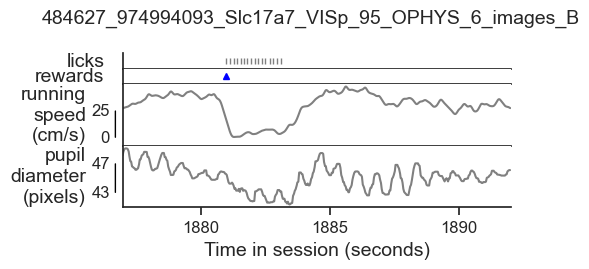

In [24]:
start_time = 1877 #519
ppf.plot_behavior_timeseries_stacked(dataset, start_time, fontsize=14,
                                     duration_seconds=15, xlim_seconds=None,
                                     label_changes=True, label_omissions=True,
                                     show_images=True, save_dir=save_dir, ax=None)

#### Another one

In [25]:
mouse_id = 425496
ophys_experiment_id = 809501118

dataset = cache.get_behavior_ophys_experiment(ophys_experiment_id)

array([<AxesSubplot:ylabel='licks'>, <AxesSubplot:ylabel='rewards'>,
       <AxesSubplot:ylabel='running\nspeed\n(cm/s)'>,
       <AxesSubplot:xlabel='Time in session (seconds)', ylabel='pupil\ndiameter\n(pixels)'>],
      dtype=object)

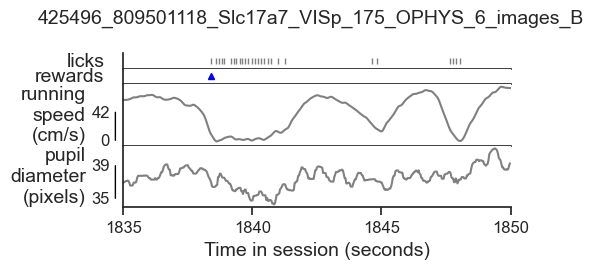

In [26]:
start_time = 1835
ppf.plot_behavior_timeseries_stacked(dataset, start_time, fontsize=14,
                                     duration_seconds=15, xlim_seconds=None,
                                     label_changes=True, label_omissions=True,
                                     show_images=True, save_dir=save_dir, ax=None)

#### Test other mice

In [27]:
# mouse_id = 436662
# ophys_experiment_id = platform_experiments[platform_experiments.mouse_id==mouse_id].index.values[0]

# dataset = cache.get_behavior_ophys_experiment(ophys_experiment_id)

# start_times = utils.get_start_times_for_period_with_hit_and_omission(dataset.stimulus_presentations, dataset.trials, n_flashes=16)

# for start_time in start_times[:20]: 
#     ppf.plot_behavior_timeseries_stacked(dataset, start_time, fontsize=14,
#                                         duration_seconds=15, xlim_seconds=None,
#                                         label_changes=True, label_omissions=True,
#                                         show_images=True, annotate_yaxis=True,
#                                         save_dir=save_dir, ax=None)

### Training history across mice

In [28]:
behavior_sessions.experience_level.unique()

array(['Training', 'Familiar', 'Novel', 'Novel +'], dtype=object)

In [29]:
behavior_sessions = utilities.add_behavior_stage_to_behavior_sessions(behavior_sessions)
behavior_sessions.behavior_stage.unique()

array(['gratings_static_training', 'gratings_flashed_training',
       'familiar_images_training', 'familiar_images_ophys',
       'familiar_images_ophys_passive', 'novel_images_ophys',
       'novel +_images_ophys_passive', 'novel +_images_ophys'],
      dtype=object)

#### Training history for all mice as rows

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Training history'}, xlabel='Session number', ylabel='Mouse number'>

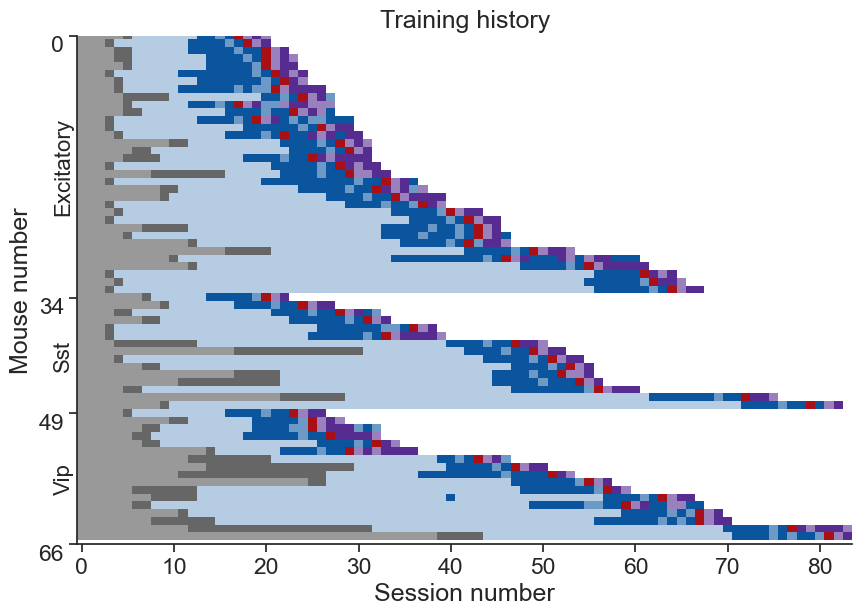

In [30]:
behavior_sessions = utilities.add_behavior_stage_to_behavior_sessions(behavior_sessions)
color_column = 'behavior_stage'
color_map = utils.get_behavior_stage_color_map(as_rgb=True)
ppf.plot_training_history_for_mice(behavior_sessions, color_column=color_column, color_map=color_map, 
                              group_by_cre_line=True, save_dir=save_dir, folder='training_history', suffix='')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Training history'}, xlabel='Session number', ylabel='Mouse number'>

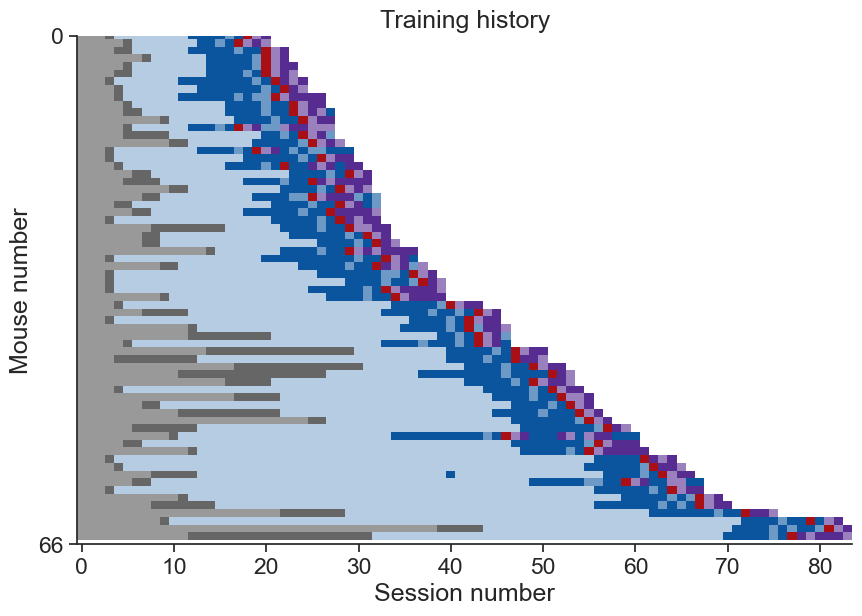

In [31]:
behavior_sessions = utilities.add_behavior_stage_to_behavior_sessions(behavior_sessions)
color_column = 'behavior_stage'
color_map = utils.get_behavior_stage_color_map(as_rgb=True)
ppf.plot_training_history_for_mice(behavior_sessions, color_column=color_column, color_map=color_map, 
                              group_by_cre_line=False, save_dir=save_dir, folder='training_history', suffix='')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Training history'}, xlabel='Session number', ylabel='Mouse number'>

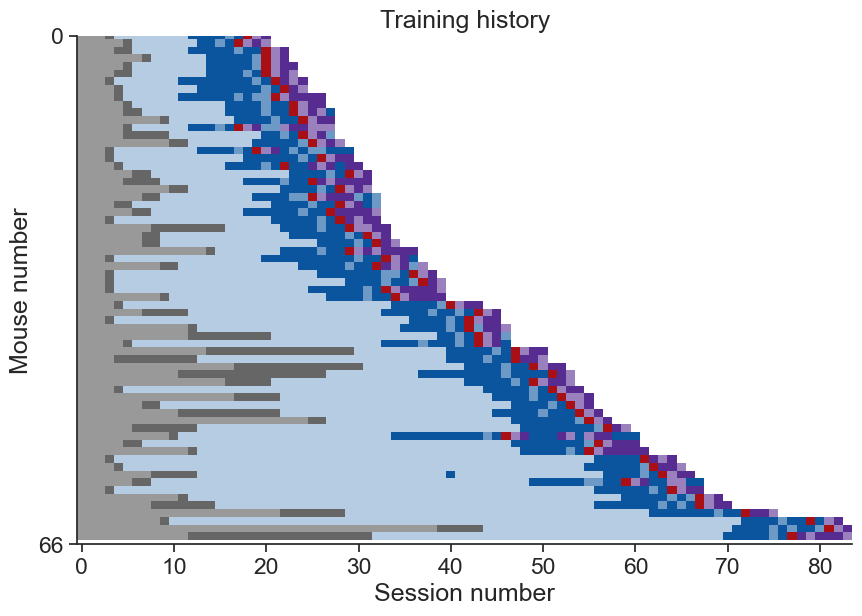

In [32]:
behavior_sessions = utilities.add_behavior_stage_to_behavior_sessions(behavior_sessions)
color_column = 'behavior_stage'
color_map = utils.get_behavior_stage_color_map(as_rgb=True)
ppf.plot_training_history_for_mice(behavior_sessions, color_column=color_column, color_map=color_map, 
                              group_by_cre_line=False, save_dir=save_dir, folder='training_history', suffix='')

#### Days in each stage

In [32]:
days_in_stage = behavior_sessions.groupby(['mouse_id', 'behavior_stage']).count().rename(columns={'equipment_name':'days_in_stage'})[['days_in_stage']]
days_in_stage = days_in_stage.reset_index()
days_in_stage = days_in_stage.merge(behavior_sessions[['mouse_id', 'cell_type', 'project_code']], on='mouse_id')
days_in_stage.head()

,mouse_id,behavior_stage,days_in_stage,cell_type,project_code
0,412036,familiar_images_ophys,3,Vip Inhibitory,VisualBehavior
1,412036,familiar_images_ophys,3,Vip Inhibitory,VisualBehavior
2,412036,familiar_images_ophys,3,Vip Inhibitory,VisualBehavior
3,412036,familiar_images_ophys,3,Vip Inhibitory,VisualBehavior
4,412036,familiar_images_ophys,3,Vip Inhibitory,VisualBehavior


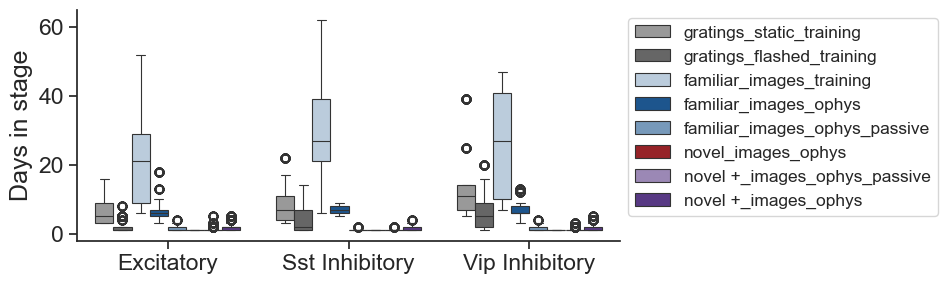

In [33]:
ppf.plot_days_in_stage(behavior_sessions, 'behavior_stage', save_dir, 'training_history', suffix='_behavior_stage')

#### Number of sessions prior to ophys sessions included in paper

In [34]:
paper_ophys_behavior_sessions = behavior_sessions.loc[platform_experiments.behavior_session_id.unique()]
prior_exposures = paper_ophys_behavior_sessions.set_index(['experience_level', 'mouse_id'])[['prior_exposures_to_image_set']].reset_index()

prior_exposures.groupby(['experience_level']).describe()[['prior_exposures_to_image_set']]

prior_exposures_to_image_set                              \
                                        count       mean        std   min   
experience_level                                                            
Familiar                                 68.0  27.264706  14.820939  10.0   
Novel                                    66.0        0.0        0.0   0.0   
Novel +                                  68.0   2.117647   0.922835   1.0   

                                            
                    25%   50%    75%   max  
experience_level                            
Familiar          14.75  22.0  36.25  68.0  
Novel               0.0   0.0    0.0   0.0  
Novel +             2.0   2.0    2.0   6.0

##### All experience levels

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3696: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=exposures, x='experience_level', y='prior_exposures_to_image_set',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3705: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(experience_levels, rotation=90)


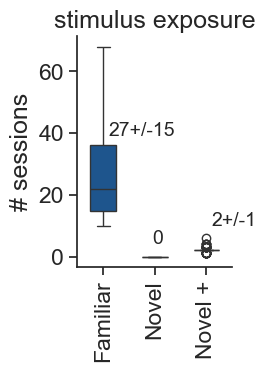

In [35]:
ppf.plot_prior_exposures_to_image_set_before_platform_ophys_sessions(platform_experiments, behavior_sessions, 
                                                                 save_dir=save_dir, folder='training_history', suffix='', ax=None)                                                                 

#### flip axes

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3816: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=exposures, y='experience_level', x='prior_exposures_to_image_set', orient='h',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3825: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(experience_levels, rotation=0)


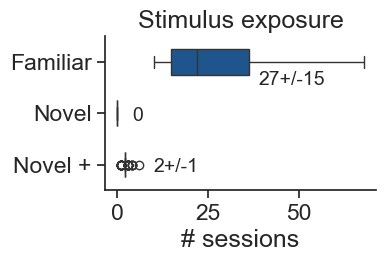

In [36]:
ppf.plot_prior_exposures_to_image_set_before_platform_ophys_sessions_horiz(platform_experiments, behavior_sessions, 
                                                                 save_dir=save_dir, folder='training_history', suffix='', ax=None)

##### Prior to Novel session

In [37]:
platform_experiments.experience_level.unique()

array(['Familiar', 'Novel', 'Novel +'], dtype=object)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3696: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=exposures, x='experience_level', y='prior_exposures_to_image_set',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3696: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.boxplot(data=exposures, x='experience_level', y='prior_exposures_to_image_set',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3705: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(experience_levels, rotation=90)


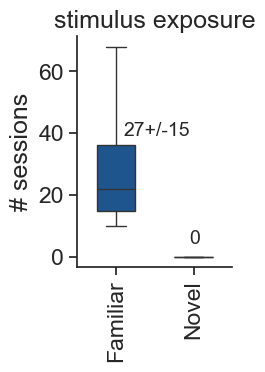

In [38]:
tmp = platform_experiments.copy()
tmp = tmp[tmp.experience_level.isin(['Familiar', 'Novel'])]

ppf.plot_prior_exposures_to_image_set_before_platform_ophys_sessions(tmp, behavior_sessions, 
                                                                 save_dir=save_dir, folder='training_history', 
                                                                 suffix='_F_N', ax=None)

#### Number of novel sessions prior to novel + for sessions included in paper

In [39]:
paper_ophys_behavior_sessions = behavior_sessions.loc[platform_experiments.behavior_session_id.unique()]

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3761: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=exposures, x='cell_type', y='prior_exposures_to_image_set', order=cell_types,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3778: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels, rotation=90, )


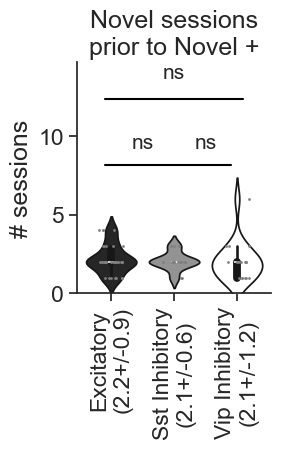

In [40]:
ppf.plot_prior_exposures_per_cell_type_for_novel_plus(platform_experiments, behavior_sessions, 
                                                  save_dir=save_dir, folder='training_history', suffix='', ax=None)

#### Total exposures for each experience level during ophys

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3871: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=exposures, x='experience_level', y='n_sessions',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3880: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xticklabels, rotation=90, )


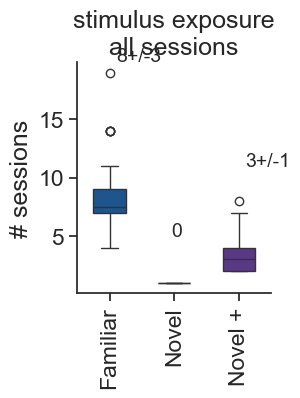

In [41]:
ppf.plot_total_stimulus_exposures(behavior_sessions, save_dir=save_dir, folder='training_history', suffix='', ax=None)

#### Exposure during training

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3938: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=exposures, x=column_to_group, y='n_sessions',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3955: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([col_value.replace('_', ' ') for col_value in col_values], rotation=90)


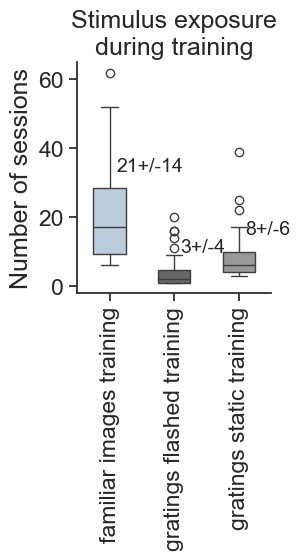

In [42]:
ppf.plot_stimulus_exposure_prior_to_imaging(behavior_sessions, column_to_group='behavior_stage', 
                                        save_dir=save_dir, folder='training_history', suffix='', ax=None)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3938: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=exposures, x=column_to_group, y='n_sessions',
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3955: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([col_value.replace('_', ' ') for col_value in col_values], rotation=90)


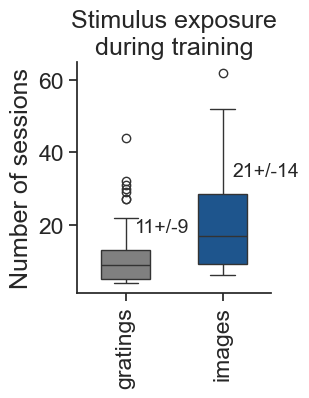

In [43]:
ppf.plot_stimulus_exposure_prior_to_imaging(behavior_sessions, column_to_group='stimulus_type', 
                                        save_dir=save_dir, folder='training_history', suffix='', ax=None)

### Load behavior performance statistics 

#### AllenSDK computed metrics

In [44]:
%%time 

method = 'sdk'
engaged_only = False
per_image = False

# folder = get_save_folder(method, engaged_only, per_image)

behavior_session_ids = behavior_sessions.index.values

original_behavior_stats_sdk, problem_sessions = vbu.get_behavior_stats_for_sessions(behavior_session_ids, behavior_sessions, 
                                    method=method, engaged_only=engaged_only, per_image=per_image)

# original_behavior_stats_sdk = original_behavior_stats_sdk.copy()
behavior_stats_sdk = original_behavior_stats_sdk.merge(behavior_sessions, on='behavior_session_id')
# behavior_stats_sdk['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in behavior_stats_sdk.experience_level.values]

# print(len(behavior_stats_sdk))

2938 behavior sessions in behavior_stats table
CPU times: total: 15.6 ms
Wall time: 266 ms


#### Behavior stats for stimulus based metrics, engaged trials only

In [45]:
%%time 

method = 'stimulus_based'
engaged_only = True
per_image = False

# folder = get_save_folder(method, engaged_only, per_image)

behavior_session_ids = behavior_sessions.index.values


original_engaged_behavior_stats_stim, problem_sessions = vbu.get_behavior_stats_for_sessions(behavior_session_ids, behavior_sessions, 
                                    method=method, engaged_only=engaged_only, per_image=per_image)

# original_behavior_stats = behavior_stats.copy()
engaged_behavior_stats_stim = original_engaged_behavior_stats_stim.merge(behavior_sessions, on='behavior_session_id')
print(len(engaged_behavior_stats_stim.mouse_id.unique()))
#  remove 4x2 sessions
engaged_behavior_stats_stim = engaged_behavior_stats_stim[engaged_behavior_stats_stim.project_code!='VisualBehaviorMultiscope4areasx2d']

2445 behavior sessions in behavior_stats table
56
CPU times: total: 0 ns
Wall time: 281 ms


In [46]:
# which sessions / mice are missing? 
missing_sessions = [bsid for bsid in behavior_sessions.index.values if bsid not in engaged_behavior_stats_stim.behavior_session_id.unique()]
missing_mice= [mouse_id for mouse_id in behavior_sessions.mouse_id.values if mouse_id not in engaged_behavior_stats_stim.mouse_id.unique()]
print(np.sort(np.unique(missing_mice)))

[425496 440631 445002 453911 461946 467954 468866 480753 547266 549976]


### Plot training history for individual mice

old figures can be found here: \\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_plots\figure_1\original\behavior_performance_over_time_stimulus_based

In [47]:
# example_mouse_ids = ['451787', '456917', '485688', '492395', '512458', '533161', 
#                      '546605', '445002', '485688', '489066', '512458', '513626']

example_mouse_ids = [512458, 456917, 485688, 492395, 533161, # 451787 not in platform expts
                     546605, 445002, 485688, 489066, 512458, 513626]

In [48]:
# check whether any of the samples are not in the platform paper eexperiments table
for mouse_id in example_mouse_ids: 
    if len(platform_experiments[platform_experiments.mouse_id==mouse_id])==0: 
        print(mouse_id)

#### Stimulus based behavior metrics

##### Plot metrics for one mouse, one metric

In [49]:
metrics = ['dprime_trial_corrected', 'dprime_non_trial_corrected', 
            'hit_rate', 'fa_rate', 'response_latency_mean', 'response_latency_std']

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4200: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=metric, hue=hue, hue_order=data[hue].unique(), linewidth='none', palette=colors, ax=ax)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[hue].values, rotation=90);


<AxesSubplot:title={'center':'512458\nExample mouse training history'}, xlabel='Session number', ylabel='d-prime'>

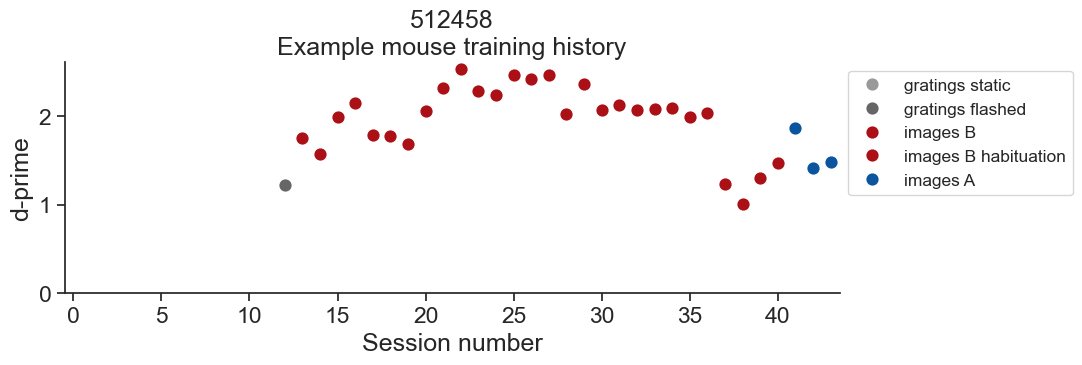

In [53]:
behavior_stats = engaged_behavior_stats_stim.copy()
mouse_id = example_mouse_ids[0]
metric = 'dprime_trial_corrected'
ylabel = 'd-prime'

ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method,
                                        x='date_of_acquisition', hue='stimulus', ylabel=ylabel, 
                                        save_dir=save_dir, folder='behavior_performance', ax=None)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4200: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=metric, hue=hue, hue_order=data[hue].unique(), linewidth='none', palette=colors, ax=ax)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[hue].values, rotation=90);


<AxesSubplot:title={'center':'512458\nExample mouse training history'}, xlabel='Session number', ylabel='d-prime'>

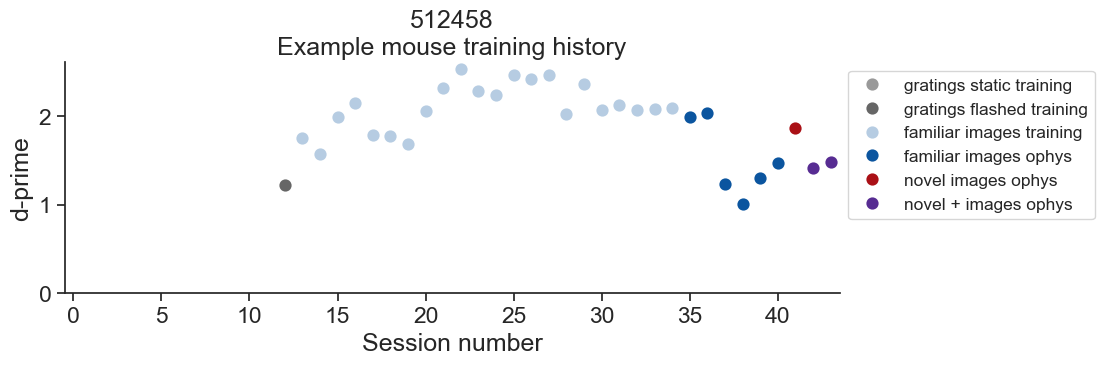

In [54]:
behavior_stats = engaged_behavior_stats_stim.copy()
mouse_id = example_mouse_ids[0]
metric = 'dprime_trial_corrected'
ylabel = 'd-prime'

ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method,
                                        x='date_of_acquisition', hue='behavior_stage', 
                                        use_session_number=True, ylabel=ylabel, 
                                        save_dir=save_dir, folder='behavior_performance', ax=None)

##### Plot performance for multiple metrics, all mice

In [55]:
# behavior_stats = engaged_behavior_stats_stim.copy()
# color_map = utils.get_stimulus_color_map(as_rgb=False)

# metrics = ['dprime_trial_corrected', 'dprime_non_trial_corrected', 'hit_rate', 'fa_rate', 'response_latency_mean', 'response_latency_std']

# for metric in metrics: 
#     for i, mouse_id in enumerate(example_mouse_ids):
#         plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method,
#                                                 x='date_of_acquisition', hue='stimulus', ylabel=None, 
#                                                 save_dir=save_dir, folder='behavior_performance', ax=None)

#### Behavior performance across mice - SDK metrics

In [56]:
metrics = ['max_dprime', 'max_dprime_engaged', 
           'mean_dprime', 'mean_dprime_engaged', 
           'mean_hit_rate', 'mean_hit_rate_engaged']

##### Plot for one mouse

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4200: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=metric, hue=hue, hue_order=data[hue].unique(), linewidth='none', palette=colors, ax=ax)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[hue].values, rotation=90);


<AxesSubplot:title={'center':'512458\nExample mouse training history'}, xlabel='Session number', ylabel='d-prime'>

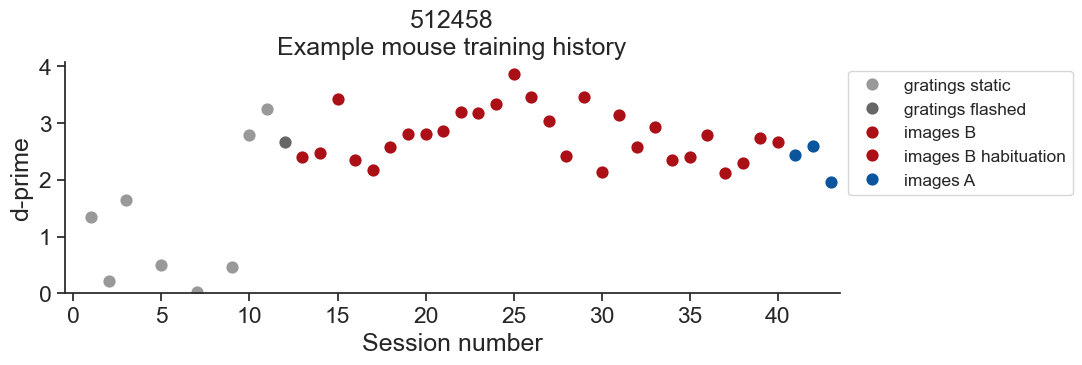

In [57]:
mouse_id = 512458

behavior_stats = behavior_stats_sdk.copy()
metric = 'max_dprime'
ylabel = 'd-prime'

ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method='sdk',
                                        x='date_of_acquisition', hue='stimulus', ylabel=ylabel, 
                                        save_dir=save_dir, folder='behavior_performance', ax=None)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4200: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=metric, hue=hue, hue_order=data[hue].unique(), linewidth='none', palette=colors, ax=ax)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[hue].values, rotation=90);


<AxesSubplot:title={'center':'512458\nExample mouse training history'}, xlabel='Session number', ylabel='d-prime'>

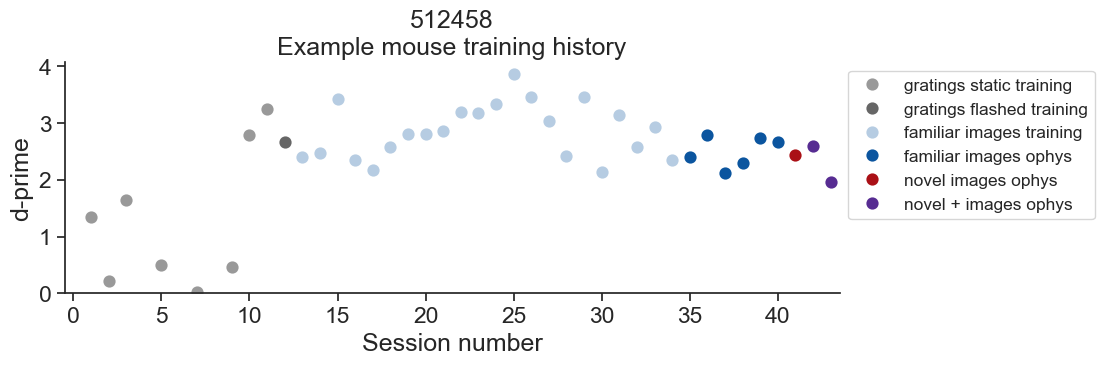

In [58]:
mouse_id = 512458

behavior_stats = behavior_stats_sdk.copy()
metric = 'max_dprime'
ylabel = 'd-prime'

ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method='sdk', remove_passive=True,
                                        x='date_of_acquisition', hue='behavior_stage', ylabel=ylabel, 
                                        save_dir=save_dir, folder='behavior_performance', ax=None)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4200: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=metric, hue=hue, hue_order=data[hue].unique(), linewidth='none', palette=colors, ax=ax)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[hue].values, rotation=90);


<AxesSubplot:title={'center':'512458\nExample mouse training history'}, xlabel='Session number', ylabel='d-prime'>

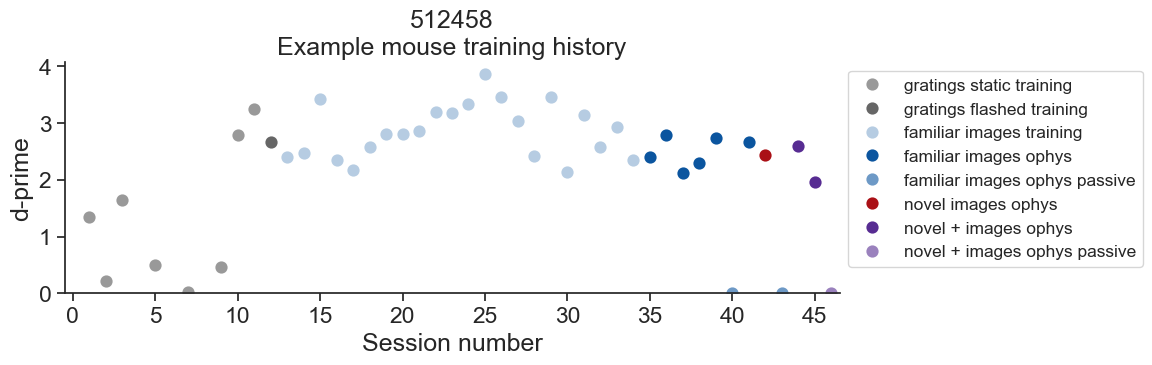

In [59]:
mouse_id = 512458

behavior_stats = behavior_stats_sdk.copy()
metric = 'max_dprime'
ylabel = 'd-prime'

ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method='sdk', remove_passive=False,
                                        x='date_of_acquisition', hue='behavior_stage', ylabel=ylabel, 
                                        save_dir=save_dir, folder='behavior_performance', ax=None)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4200: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=metric, hue=hue, hue_order=data[hue].unique(), linewidth='none', palette=colors, ax=ax)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[hue].values, rotation=90);


<AxesSubplot:title={'center':'425496\nExample mouse training history'}, xlabel='Session number', ylabel='d-prime'>

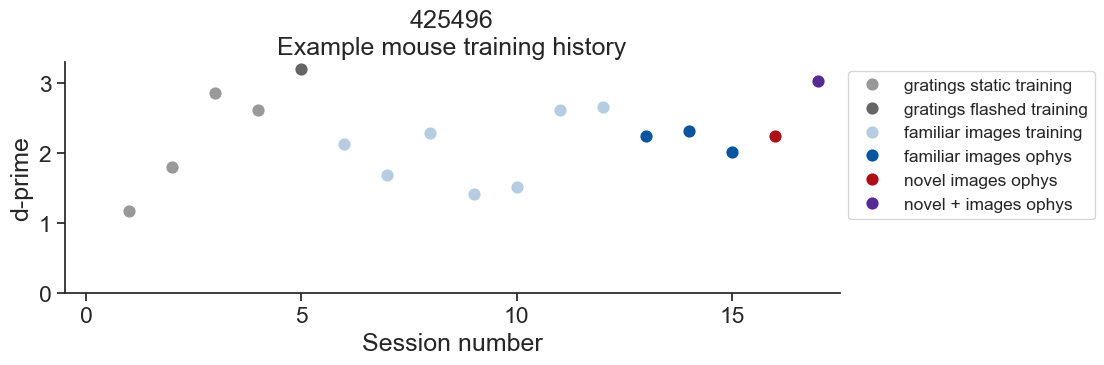

In [60]:
mouse_id = 425496

behavior_stats = behavior_stats_sdk.copy()
metric = 'max_dprime'
ylabel = 'd-prime'

ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method='sdk',
                                        x='date_of_acquisition', hue='behavior_stage', ylabel=ylabel, 
                                        save_dir=save_dir, folder='behavior_performance', ax=None)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4200: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=metric, hue=hue, hue_order=data[hue].unique(), linewidth='none', palette=colors, ax=ax)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[hue].values, rotation=90);


<AxesSubplot:title={'center':'425496\nExample mouse training history'}, xlabel='Session number', ylabel='d-prime'>

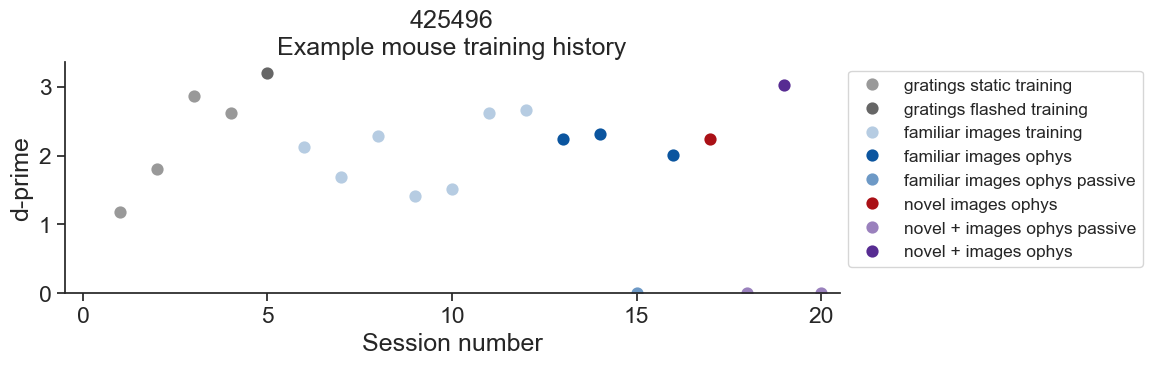

In [61]:
mouse_id = 425496

behavior_stats = behavior_stats_sdk.copy()
metric = 'max_dprime'
ylabel = 'd-prime'

ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method='sdk', remove_passive=False,
                                        x='date_of_acquisition', hue='behavior_stage', ylabel=ylabel, 
                                        save_dir=save_dir, folder='behavior_performance', ax=None)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4200: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=metric, hue=hue, hue_order=data[hue].unique(), linewidth='none', palette=colors, ax=ax)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[hue].values, rotation=90);


<AxesSubplot:title={'center':'512458\nExample mouse training history'}, xlabel='Session number', ylabel='d-prime'>

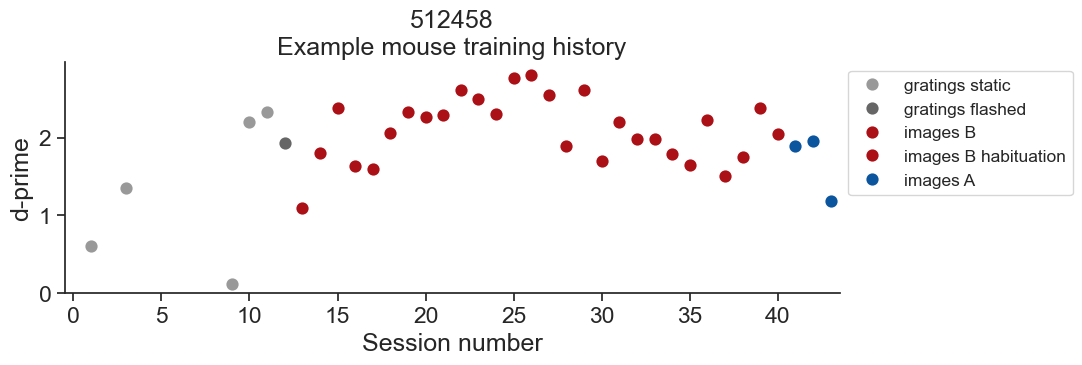

In [62]:
behavior_stats = behavior_stats_sdk.copy()
mouse_id = example_mouse_ids[0]
metric = 'mean_dprime_engaged'
ylabel = 'd-prime'

ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method='sdk',
                                        x='date_of_acquisition', hue='stimulus', ylabel=ylabel, 
                                        save_dir=save_dir, folder='behavior_performance', ax=None)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4200: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=metric, hue=hue, hue_order=data[hue].unique(), linewidth='none', palette=colors, ax=ax)
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4202: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(data[hue].values, rotation=90);


<AxesSubplot:title={'center':'512458\nExample mouse training history'}, xlabel='Session number', ylabel='d-prime'>

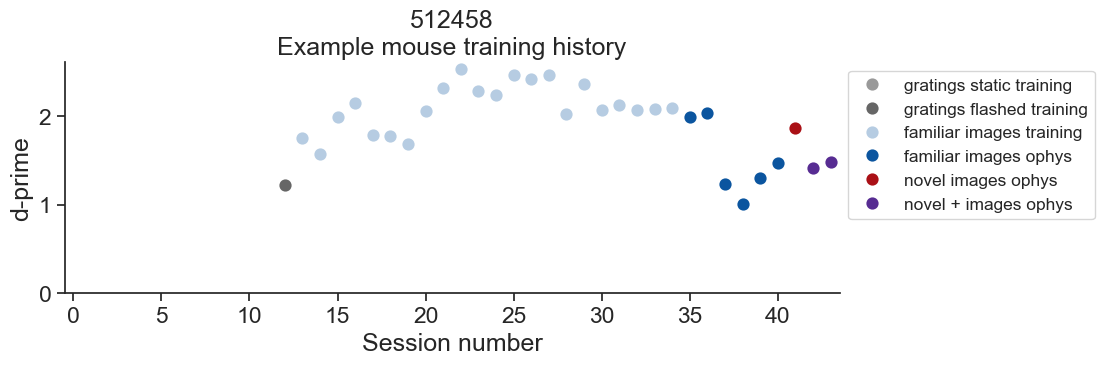

In [63]:
behavior_stats = engaged_behavior_stats_stim.copy()
mouse_id = example_mouse_ids[0]
metric = 'dprime_trial_corrected'
ylabel = 'd-prime'

ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method='stim_based',
                                            hue='behavior_stage', use_session_number=True, ylabel=ylabel, 
                                            save_dir=save_dir, folder='behavior_performance', ax=None)

##### Plot for multiple mice and metrics

In [64]:
# behavior_stats = behavior_stats_sdk.copy()
# color_map = utils.get_stimulus_color_map(as_rgb=False)

# metrics = ['max_dprime', 'max_dprime_engaged', 
#            'mean_dprime', 'mean_dprime_engaged', 
#            'mean_hit_rate', 'mean_hit_rate_engaged']

# for metric in metrics: 
#     for i, mouse_id in enumerate(example_mouse_ids):
#         ppf.plot_behavior_performance_for_one_mouse(behavior_stats, mouse_id, metric, method='sdk', remove_passive=False,
#                                             hue='behavior_stage', use_session_number=True, ylabel=ylabel, 
#                                             save_dir=save_dir, folder='behavior_performance_with_passive', ax=None)

### Plot response probability across conditions 

* get passing ophys sessions, included in platform paper
* load each dataset, annotate stimulus presentations with licks, post-omission, 'could change' etc
* compute summary metrics per session (engaged only and full session) and save

In [65]:
ophys_behavior_sessions = behavior_sessions[(behavior_sessions.session_type.str.contains('OPHYS'))&(behavior_sessions.passive==False)]
print(len(ophys_behavior_sessions))

642


In [66]:
platform_behavior_sessions = behavior_sessions[behavior_sessions.ophys_session_id.isin(platform_experiments.ophys_session_id.unique())]
len(platform_behavior_sessions)

202

#### Calculate for all platform behavior experiments

This is very slow, better to use saved file

In [67]:
# import brain_observatory_utilities.datasets.behavior.data_formatting as behavior_formatting

# stim_save_dir = os.path.join(loading.get_platform_analysis_cache_dir(), 'annotated_stimulus_presentations')

# platform_behavior_stats = pd.DataFrame()
# for behavior_session_id in platform_behavior_sessions.index.values: 

#         print(np.where(platform_behavior_sessions.index.values==behavior_session_id)[0][0], 'out of', len(platform_behavior_sessions))

#         annotated_stim_presentations_path = os.path.join(stim_save_dir, str(behavior_session_id)+'.h5')
        
#         # try to load previously saved annoated stim presentations, if not, generate and save it
#         if os.path.exists(annotated_stim_presentations_path):
#                 stimulus_presentations = pd.read_hdf(annotated_stim_presentations_path, key='df')

#         else:
#                 dataset = cache.get_behavior_session(behavior_session_id)

#                 stimulus_presentations = behavior_formatting.get_annotated_stimulus_presentations(dataset)

#                 # stim_presentations = behavior_formatting.annotate_stimuli(dataset)
#                 # stimulus_presentations = stimulus_presentations.merge(stim_presentations[['could_change', 'previous_image_name', 'response_lick']], on='stimulus_presentations_id')

#                 stimulus_presentations.to_hdf(annotated_stim_presentations_path, key='df')

#         try: # compute stats from annotated stim presentations and add to table for all sessions
#                 # this function limits metrics calciulation to engaged periods (stim_presentations['engaged]=True)
#                 behavior_stats = loading.get_behavior_stats_from_stimulus_presentations(stimulus_presentations)
#                 behavior_stats['behavior_session_id'] = behavior_session_id

#                 platform_behavior_stats = pd.concat([platform_behavior_stats, behavior_stats])
#         except: 
#                 print('behavior stats not added for', behavior_session_id)

# # platform_behavior_stats.to_csv(os.path.join(save_dir, 'platform_behavior_stats_engaged.csv'))


In [68]:
platform_behavior_stats = pd.read_csv(os.path.join(cache_dir, 'behavior_performance', 'platform_behavior_stats_engaged.csv'), index_col=0)


#### Plot response probability for different stimulus presentation conditions - changes, non-changes, omissions, post-omissions

C:\Users\marinag\AppData\Local\Temp\ipykernel_5048\2245655122.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)


(-0.01, 1.0)

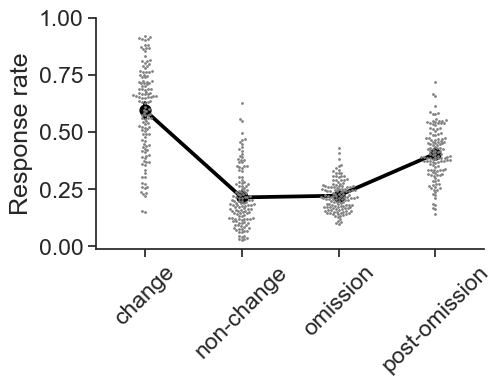

In [69]:
data = platform_behavior_stats.copy()
data = data[data.fraction_engaged>0.7]
data = data[data.trial_type.isin(['change', 'could_change', 'omission', 'post-omission'])]
data['trial_type'] = ['non-change' if trial_type == 'could_change' else trial_type for trial_type in data.trial_type.values]

trial_types = data.trial_type.unique()
figsize = (5,3)
fig, ax = plt.subplots(figsize=figsize)
ax = sns.pointplot(data=data, x='trial_type', y='response_probability', 
                   order=trial_types, color='k', ax=ax)
ax = sns.swarmplot(data=data, x='trial_type', y='response_probability', 
                   order=trial_types, color='gray', s=2, ax=ax)
ax.set_ylabel('Response rate')
ax.set_xticklabels(trial_types, rotation=45)
ax.set_xlabel('')
ax.set_ylim(-0.01, 1)

C:\Users\marinag\AppData\Local\Temp\ipykernel_5048\276915288.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x='trial_type', y='response_probability',
C:\Users\marinag\AppData\Local\Temp\ipykernel_5048\276915288.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)


(-0.01, 0.8)

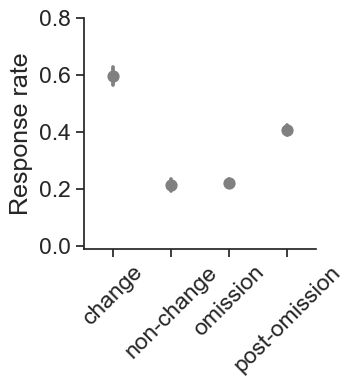

In [70]:
data = platform_behavior_stats.copy()
data = platform_behavior_stats.merge(behavior_sessions, on='behavior_session_id')
data = data[data.fraction_engaged>0.7]
data = data[data.trial_type.isin(['change', 'could_change', 'omission', 'post-omission'])]
data['trial_type'] = ['non-change' if trial_type == 'could_change' else trial_type for trial_type in data.trial_type.values]

trial_types = data.trial_type.unique()
figsize = (3, 3)
fig, ax = plt.subplots(figsize=figsize)
ax = sns.pointplot(data=data, x='trial_type', y='response_probability',
                   order=trial_types, color='gray', join=False, ax=ax)
# ax = sns.swarmplot(data=data, x='trial_type', y='response_probability',
#                    order=trial_types, color='gray', size=2, ax=ax)
# ax = sns.boxplot(data=data, x='trial_type', y='response_probability',
#                    order=trial_types, width=0.5, color='white', ax=ax)
# ax = sns.swarmplot(data=data, x='trial_type', y='response_probability', 
#                    order=trial_types, color='gray', s=2, ax=ax)
ax.set_ylabel('Response rate')
ax.set_xticklabels(trial_types, rotation=45)
ax.set_xlabel('')
ax.set_ylim(-0.01, 0.8)

C:\Users\marinag\AppData\Local\Temp\ipykernel_5048\3011608387.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)


(-0.01, 1.0)

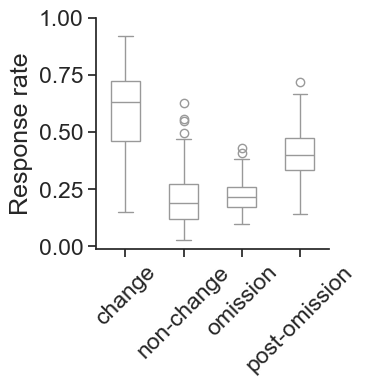

In [71]:
data = platform_behavior_stats.copy()
data = platform_behavior_stats.merge(behavior_sessions, on='behavior_session_id')
data = data[data.fraction_engaged>0.7]
data = data[data.trial_type.isin(['change', 'could_change', 'omission', 'post-omission'])]
data['trial_type'] = ['non-change' if trial_type == 'could_change' else trial_type for trial_type in data.trial_type.values]

trial_types = data.trial_type.unique()
figsize = (3, 3)
fig, ax = plt.subplots(figsize=figsize)
# ax = sns.pointplot(data=data, x='trial_type', y='response_probability',
#                    order=trial_types, color='gray', join=False, ax=ax)
# ax = sns.swarmplot(data=data, x='trial_type', y='response_probability',
#                    order=trial_types, color='gray', size=2, ax=ax)
ax = sns.boxplot(data=data, x='trial_type', y='response_probability',
                   order=trial_types, width=0.5, color='white', ax=ax)
# ax = sns.swarmplot(data=data, x='trial_type', y='response_probability', 
#                    order=trial_types, color='gray', s=2, ax=ax)
ax.set_ylabel('Response rate')
ax.set_xticklabels(trial_types, rotation=45)
ax.set_xlabel('')
ax.set_ylim(-0.01, 1)

In [72]:
# is this consistent with hit and fa rate computed by SDK?
tmp = behavior_stats_sdk.copy()
tmp = tmp[tmp.behavior_session_id.isin(platform_behavior_sessions.index.values)]
tmp = tmp[tmp.session_type.str.contains('OPHYS')]
len(tmp.behavior_session_id.unique())
print(tmp.mean_hit_rate_engaged.mean())
print(tmp.mean_false_alarm_rate_engaged.mean())

0.6708138475718537
0.31063608741197446


C:\Users\marinag\AppData\Local\Temp\ipykernel_5048\361113097.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)


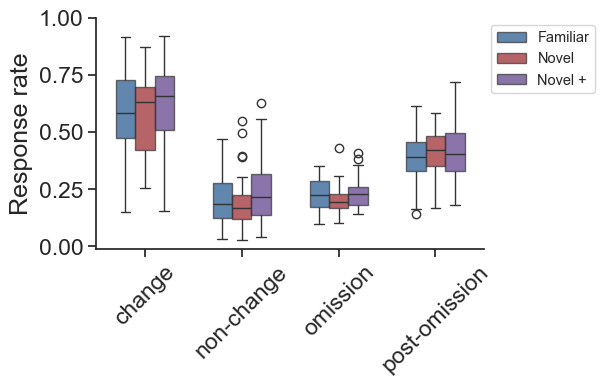

In [ ]:
data = platform_behavior_stats.merge(behavior_sessions, on='behavior_session_id')
data = data[data.fraction_engaged>0.7]
data = data[data.trial_type.isin(['change', 'could_change', 'omission', 'post-omission'])]
data['trial_type'] = ['non-change' if trial_type == 'could_change' else trial_type for trial_type in data.trial_type.values]

trial_types = data.trial_type.unique()
figsize = (5,3)
fig, ax = plt.subplots(figsize=figsize)
ax = sns.boxplot(data=data, x='trial_type', y='response_probability', hue='experience_level',
                   order=trial_types, palette=utils.get_experience_level_colors(), width=0.6, boxprops=dict(alpha=0.7), ax=ax)
# ax = sns.swarmplot(data=data, x='trial_type', y='response_probability', 
#                    order=trial_types, color='gray', s=2, ax=ax)
ax.set_ylabel('Response rate')
ax.set_xticklabels(trial_types, rotation=45)
ax.set_xlabel('')
ax.set_ylim(-0.01, 1)
ax.legend(bbox_to_anchor=(1,1), fontsize='xx-small')

#### Plot response rate for go and catch trials

##### Stimulus based metric calculation

In [74]:
# stats = engaged_behavior_stats_stim[engaged_behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
stats = engaged_behavior_stats_stim.copy()

stats = stats[['hit_rate', 'fa_rate', 'behavior_session_id']].melt(id_vars='behavior_session_id')
stats['response_probability'] = stats['value']
stats['trial_type'] = stats['variable']
stats['trial_type'] = [trial_type.split('_')[0] for trial_type in stats.trial_type.values]

stats.head()

,behavior_session_id,variable,value,response_probability,trial_type
0,760808911,hit_rate,NaN,NaN,hit
1,761294708,hit_rate,NaN,NaN,hit
2,761730617,hit_rate,NaN,NaN,hit
3,762067130,hit_rate,NaN,NaN,hit
4,762418364,hit_rate,NaN,NaN,hit


In [75]:
stats = stats.merge(behavior_sessions[['mouse_id', 'experience_level', 'cell_type', 'session_type']], on='behavior_session_id')
stats.head()

,behavior_session_id,variable,value,response_probability,trial_type,mouse_id,experience_level,cell_type,session_type
0,760808911,hit_rate,NaN,NaN,hit,412036,Training,Vip Inhibitory,TRAINING_0_gratings_autorewards_15min
1,760808911,fa_rate,NaN,NaN,fa,412036,Training,Vip Inhibitory,TRAINING_0_gratings_autorewards_15min
2,761294708,hit_rate,NaN,NaN,hit,412036,Training,Vip Inhibitory,TRAINING_1_gratings
3,761294708,fa_rate,NaN,NaN,fa,412036,Training,Vip Inhibitory,TRAINING_1_gratings
4,761730617,hit_rate,NaN,NaN,hit,412036,Training,Vip Inhibitory,TRAINING_1_gratings


C:\Users\marinag\AppData\Local\Temp\ipykernel_5048\2900703055.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)


(-0.01, 1.0)

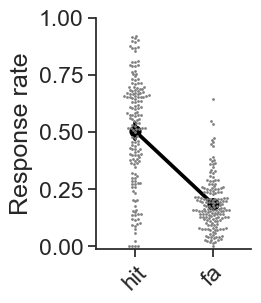

In [76]:
# platform ophys sessions
data = stats.copy()
data = data[data.behavior_session_id.isin(platform_behavior_sessions.index.values)]

trial_types = data.trial_type.unique()
figsize = (2, 3)
fig, ax = plt.subplots(figsize=figsize)
ax = sns.pointplot(data=data, x='trial_type', y='response_probability', 
                   order=trial_types, color='k', ax=ax)
ax = sns.swarmplot(data=data, x='trial_type', y='response_probability', 
                   order=trial_types, color='gray', s=2, ax=ax)
ax.set_ylabel('Response rate')
ax.set_xticklabels(trial_types, rotation=45)
ax.set_xlabel('')
ax.set_ylim(-0.01, 1)

C:\Users\marinag\AppData\Local\Temp\ipykernel_5048\3729886526.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)


(-0.01, 1.0)

c:\Users\marinag\Anaconda3\envs\visual_behavior_sdk_new\lib\site-packages\seaborn\categorical.py:3370: UserWarning: 7.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


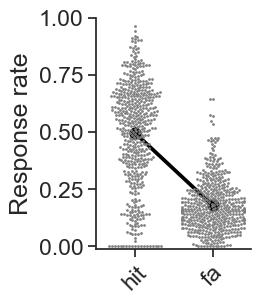

In [77]:
# ophys sessions
data = stats.copy()
data = data[data.session_type.str.contains('OPHYS')]

trial_types = data.trial_type.unique()
figsize = (2, 3)
fig, ax = plt.subplots(figsize=figsize)
ax = sns.pointplot(data=data, x='trial_type', y='response_probability', 
                   order=trial_types, color='k', ax=ax)
ax = sns.swarmplot(data=data, x='trial_type', y='response_probability', 
                   order=trial_types, color='gray', s=2, ax=ax)
ax.set_ylabel('Response rate')
ax.set_xticklabels(trial_types, rotation=45)
ax.set_xlabel('')
ax.set_ylim(-0.01, 1)

In [78]:
tmp = behavior_stats_sdk.copy()
tmp = tmp[tmp.behavior_session_id.isin(platform_behavior_sessions.index.values)]
tmp = tmp[tmp.session_type.str.contains('OPHYS')]
len(tmp.behavior_session_id.unique())
print(tmp.mean_hit_rate_engaged.mean())
print(tmp.mean_false_alarm_rate_engaged.mean())

0.6708138475718537
0.31063608741197446


In [79]:
# # ophys sessions
# data = behavior_stats_sdk.copy()
# data = data[data.session_type.str.contains('OPHYS')]

# trial_types = data.trial_type.unique()
# figsize = (2, 3)
# fig, ax = plt.subplots(figsize=figsize)
# ax = sns.pointplot(data=data, x='trial_type', y='mean_hit_rate_engaged', 
#                    order=trial_types, color='k', ax=ax)
# ax = sns.swarmplot(data=data, x='trial_type', y='mean_hit_rate_engageda', 
#                    order=trial_types, color='gray', s=2, ax=ax)
# ax.set_ylabel('Response rate')
# ax.set_xticklabels(trial_types, rotation=45)
# ax.set_xlabel('')
# ax.set_ylim(-0.01, 1)

c:\Users\marinag\Anaconda3\envs\visual_behavior_sdk_new\lib\site-packages\seaborn\categorical.py:3370: UserWarning: 9.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\marinag\Anaconda3\envs\visual_behavior_sdk_new\lib\site-packages\seaborn\categorical.py:3370: UserWarning: 31.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\marinag\AppData\Local\Temp\ipykernel_5048\2232504817.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)


(-0.01, 1.0)

c:\Users\marinag\Anaconda3\envs\visual_behavior_sdk_new\lib\site-packages\seaborn\categorical.py:3370: UserWarning: 33.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\marinag\Anaconda3\envs\visual_behavior_sdk_new\lib\site-packages\seaborn\categorical.py:3370: UserWarning: 51.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


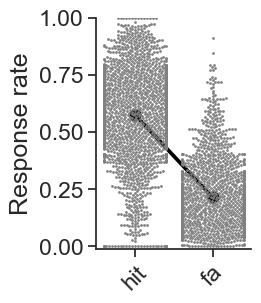

In [80]:
# full dataset
data = stats.copy()

trial_types = data.trial_type.unique()
figsize = (2, 3)
fig, ax = plt.subplots(figsize=figsize)
ax = sns.pointplot(data=data, x='trial_type', y='response_probability', 
                   order=trial_types, color='k', ax=ax)
ax = sns.swarmplot(data=data, x='trial_type', y='response_probability', 
                   order=trial_types, color='gray', s=2, ax=ax)
ax.set_ylabel('Response rate')
ax.set_xticklabels(trial_types, rotation=45)
ax.set_xlabel('')
ax.set_ylim(-0.01, 1)

##### Using AllenSDK performance metrics

In [81]:
# stats = engaged_behavior_stats_stim[engaged_behavior_stats_stim.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
stats = behavior_stats_sdk.copy()

stats = stats[['mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged', 'behavior_session_id']].melt(id_vars='behavior_session_id')
stats['response_probability'] = stats['value']
stats['trial_type'] = stats['variable']
stats['trial_type'] = ['change' if 'hit' in trial_type else 'non-change' for trial_type in stats.trial_type.values]

stats = stats.merge(behavior_sessions[['mouse_id', 'experience_level', 'cell_type', 'session_type']], on='behavior_session_id')
stats.head()

,behavior_session_id,variable,value,response_probability,trial_type,mouse_id,experience_level,cell_type,session_type
0,760808911,mean_hit_rate_engaged,NaN,NaN,change,412036,Training,Vip Inhibitory,TRAINING_0_gratings_autorewards_15min
1,760808911,mean_false_alarm_rate_engaged,NaN,NaN,non-change,412036,Training,Vip Inhibitory,TRAINING_0_gratings_autorewards_15min
2,761294708,mean_hit_rate_engaged,0.382323,0.382323,change,412036,Training,Vip Inhibitory,TRAINING_1_gratings
3,761294708,mean_false_alarm_rate_engaged,0.468123,0.468123,non-change,412036,Training,Vip Inhibitory,TRAINING_1_gratings
4,761730617,mean_hit_rate_engaged,0.681158,0.681158,change,412036,Training,Vip Inhibitory,TRAINING_1_gratings


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4235: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)


<AxesSubplot:ylabel='Response rate'>

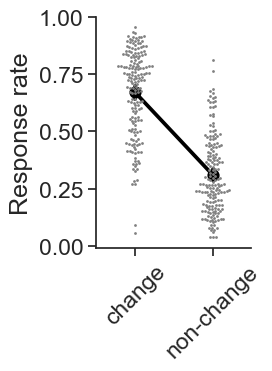

In [82]:
# platform ophys sessions
data = stats.copy()
data = data[data.behavior_session_id.isin(platform_behavior_sessions.index.values)]

suffix = '_sdk_platform_behavior_sessions'

ppf.plot_response_rate_trial_types(data, save_dir=save_dir, suffix=suffix, ax=None)


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4235: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)


<AxesSubplot:ylabel='Response rate'>

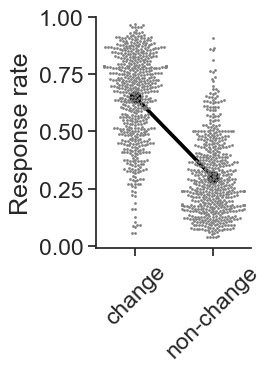

In [83]:

# all ophys sessions
data = stats.copy()
data = data[data.session_type.str.contains('OPHYS')]

suffix = '_sdk_platform_ophys_sessions'

ppf.plot_response_rate_trial_types(data, save_dir=save_dir, suffix=suffix, ax=None)


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:4235: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(trial_types, rotation=45)
c:\Users\marinag\Anaconda3\envs\visual_behavior_sdk_new\lib\site-packages\seaborn\categorical.py:3370: UserWarning: 6.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:ylabel='Response rate'>

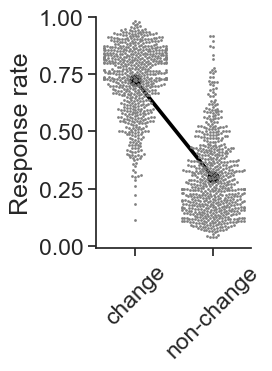

In [84]:
# handoff ready sessions
data = stats.copy()
data = data[data.session_type.str.contains('handoff_ready')]


suffix = '_sdk_handoff_ready'

ppf.plot_response_rate_trial_types(data, save_dir=save_dir, suffix=suffix, ax=None)


### Plot d-prime across conditions

#### AllenSDK metrics

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<AxesSubplot:title={'center':'behavior\nperformance'}, ylabel='d-prime'>

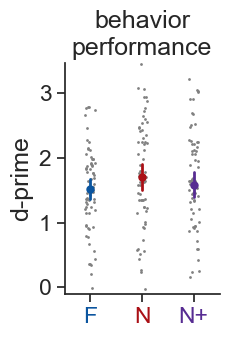

In [191]:
# only data in physiology dataset
metric = 'max_dprime'

# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()

stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
# stats = stats[(stats.experience_level.isin(['Familiar', 'Novel']))]


suffix = '_sdk_platform_experiments'

ppf.plot_behavior_metric_by_experience(stats, metric, title='behavior\nperformance', ylabel='d-prime', ylims=[-0.1, 3.3],
                                       best_image=False, show_mice=False, plot_stats=True, 
                                       stripplot=True, show_ns=False, 
                                       save_dir=save_dir, folder='behavior_metrics', suffix=suffix)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:1587: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=y, hue='experience_level', order=order,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:1644: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


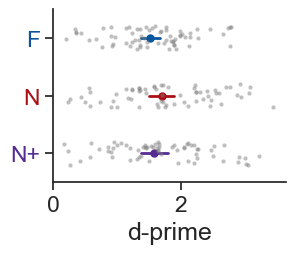

In [193]:
metric = 'max_dprime'
ylabel = 'd-prime'
event_type = 'changes'

# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()

stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

suffix = '_sdk'

ppf.plot_metric_distribution_by_experience_no_cell_type(stats, metric, event_type, 'd-prime', 
                                            ylabel=ylabel, ylims=(0, 2.8), show_mice=False,
                                            pointplot=True, stripplot=True, horiz=True,
                                            show_ns=False, add_zero_line=False, abbreviate_exp=True, save_dir=save_dir);

# ppf.plot_metric_distribution_all_conditions(metrics_table, metric, event_type, 'running_speed', ylabel=ylabel, ylims=ylims, 
#                                             add_zero_line=False, save_dir=save_dir)

please provide ylims


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:1583: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=data, x=x, y=y, hue='experience_level', order=order,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:1640: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


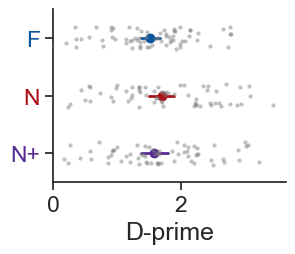

In [95]:
metric = 'max_dprime'
ylabel = 'D-prime'
event_type = 'changes'

# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()

stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

suffix = '_sdk'

ppf.plot_metric_distribution_by_experience_no_cell_type(stats, metric, event_type, 'running_speed', 
                                            ylabel=ylabel, ylims=None, show_mice=False,
                                            pointplot=True, stripplot=True, horiz=True,
                                            show_ns=False, add_zero_line=False, abbreviate_exp=True, save_dir=save_dir);

# ppf.plot_metric_distribution_all_conditions(metrics_table, metric, event_type, 'running_speed', ylabel=ylabel, ylims=ylims, 
#                                             add_zero_line=False, save_dir=save_dir)

#### Flip axis

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, y='experience_level', x=metric, order=experience_levels,


<AxesSubplot:title={'center':'Behavior performance'}, xlabel='d-prime'>

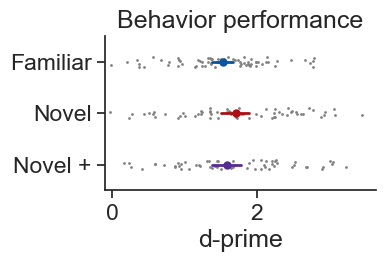

In [197]:
# only data in physiology dataset
metric = 'max_dprime'

# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()

stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
# stats = stats[(stats.experience_level.isin(['Familiar', 'Novel']))]


suffix = '_sdk_platform_experiments'

ppf.plot_behavior_metric_by_experience_horiz(stats, metric, title='Behavior performance', xlabel='d-prime', xlims=[-0.1, 3.3],
                                       best_image=False, show_containers=False, plot_stats=False, stripplot=True, show_ns=False,
                                       save_dir=save_dir, folder='behavior_metrics', suffix=suffix)

#### without N+

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<AxesSubplot:title={'center':'behavior\nperformance'}, ylabel='d-prime'>

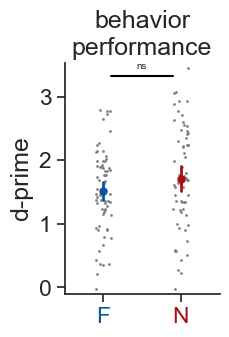

In [194]:
# only data in physiology dataset
metric = 'max_dprime'

# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()

stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
stats = stats[(stats.experience_level.isin(['Familiar', 'Novel']))]


suffix = '_sdk_platform_experiments_F_N'

ppf.plot_behavior_metric_by_experience(stats, metric, title='behavior\nperformance', ylabel='d-prime', ylims=[-0.1, 3.3],
                                       best_image=False, show_mice=False, plot_stats=True, stripplot=True, show_ns=True,
                                       save_dir=save_dir, folder='behavior_metrics', suffix=suffix)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<AxesSubplot:title={'center':'behavior\nperformance'}, ylabel='d-prime'>

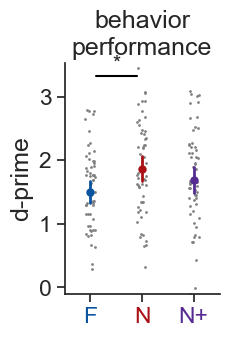

In [195]:
metric = 'max_dprime_engaged'
# only data in physiology dataset

stats = behavior_stats_sdk.copy()

stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
# stats = stats[(stats.experience_level.isin(['Familiar', 'Novel']))]


suffix = '_sdk_platform_experiments'

ppf.plot_behavior_metric_by_experience(stats, metric, title='behavior\nperformance', ylabel='d-prime', ylims=[-0.1, 3.3],
                                       best_image=False, show_mice=False, plot_stats=True, stripplot=True, show_ns=False,
                                       save_dir=save_dir, folder='behavior_metrics', suffix=suffix)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


<AxesSubplot:title={'center':'behavior\nperformance'}, ylabel='d-prime'>

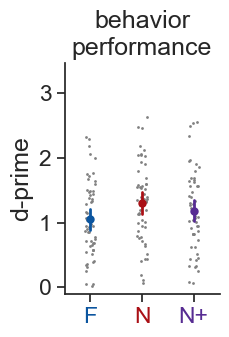

In [198]:
metric = 'mean_dprime_engaged'

# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()
stats = stats[stats[metric]>0]
stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

suffix = '_sdk_platform_experiments'

ppf.plot_behavior_metric_by_experience(stats, metric, title='behavior\nperformance', ylabel='d-prime', ylims=[-0.1, 3.3],
                                       best_image=False, show_mice=False, plot_stats=True, stripplot=True, show_ns=False,
                                       save_dir=save_dir, folder='behavior_metrics', suffix=suffix)

### Plot behavior performance across cohorts

In [103]:
len(stats.mouse_id.unique())

63

In [104]:
len(platform_experiments.mouse_id.unique())

66

#### SDK metrics

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3329: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3337: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3329: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3337: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3329: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3337: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats


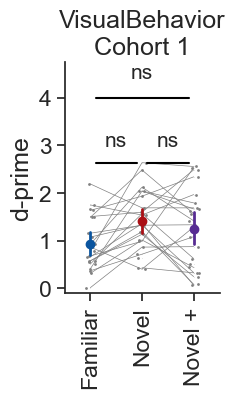

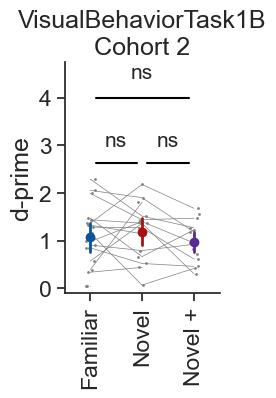

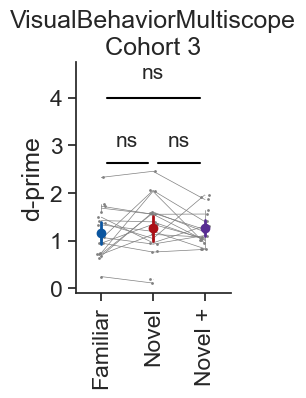

In [ ]:
metric = 'mean_dprime_engaged'

# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()
stats = stats[stats[metric]>0]
stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
# turn ophys_container_id to mouse_id so that across mouse / container plotting works
stats['ophys_container_id'] = stats['mouse_id']


suffix = '_sdk_platform_experiments'

project_codes = ['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope']

for i, project_code in enumerate(project_codes): 
    title = project_code+'\nCohort '+str(i+1)
    tmp = stats[stats.project_code==project_code]

    suffix = '_sdk_'+project_code

    ppf.plot_behavior_metric_by_experience(tmp, metric, title=title, ylabel='d-prime', ylims=[-0.1, 2.5], 
                                        best_image=False, show_mice=True, plot_stats=True, stripplot=True, show_ns=True,
                                        save_dir=save_dir, folder='behavior_metrics', suffix=suffix)

In [186]:
stats.groupby(['project_code', 'mouse_id']).count().reset_index().groupby(['project_code']).count()

,mouse_id,behavior_session_id,trial_count_x,go_trial_count_x,catch_trial_count_x,hit_trial_count_x,miss_trial_count_x,false_alarm_trial_count_x,correct_reject_trial_count_x,auto_reward_count,...,exp_level,engagement,behavior_stage,stimulus_experience_level,date,n_relative_to_first_novel,first_novel,second_novel_active,last_familiar_active,fraction_trials_engaged
project_code,,,,,,,,,,,,,,,,,,,,,
VisualBehavior,24,24,24,24,24,24,24,24,24,24,...,24,24,24,24,24,24,24,24,24,24
VisualBehaviorMultiscope,19,19,19,19,19,19,19,19,19,19,...,19,19,19,19,19,19,19,19,19,19
VisualBehaviorTask1B,20,20,20,20,20,20,20,20,20,20,...,20,20,20,20,20,20,20,20,20,20


In [182]:
project_codes

['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope']

0 VisualBehavior


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats
stats did not save for mean_dprime_engaged
1 VisualBehaviorTask1B


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats
stats did not save for mean_dprime_engaged
2 VisualBehaviorMultiscope


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats
stats did not save for mean_dprime_engaged


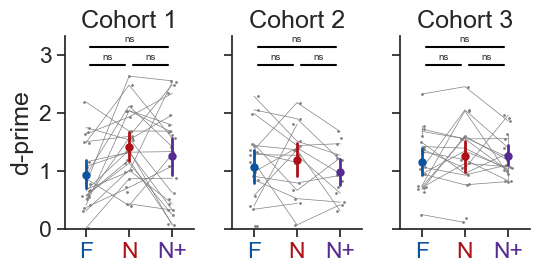

In [221]:
metric = 'mean_dprime_engaged'
ylabel = 'd-prime'
ylims = (0, 2.8)
# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()
stats = stats[stats[metric]>0]
stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
stats = stats[stats.mouse_id.isin(platform_experiments.mouse_id.unique())]

# turn ophys_container_id to mouse_id so that across mouse / container plotting works
stats['ophys_container_id'] = stats['mouse_id']


suffix = '_sdk_platform_experiments'

figsize = (6, 2.5)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
for i, project_code in enumerate(project_codes): 
    print(i, project_code)
    title = 'Cohort '+str(i+1)
    tmp = stats[stats.project_code==project_code]

    suffix = '_stim_based_cohorts'

    ax[i] = ppf.plot_behavior_metric_by_experience(tmp, metric, title=title, ylabel=ylabel, ylims=ylims,
                                        best_image=False, show_mice=True, plot_stats=True, stripplot=True, show_ns=True,
                                        save_dir=None, folder='behavior_metrics', suffix=suffix, ax=ax[i])
    ax[i].set_title(title)
fig.subplots_adjust(wspace=0.3)
utils.save_figure(fig, figsize, save_dir, 'behavior_metrics', metric + suffix)

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats
stats did not save for max_dprime_engaged


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats
stats did not save for max_dprime_engaged


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats
stats did not save for max_dprime_engaged


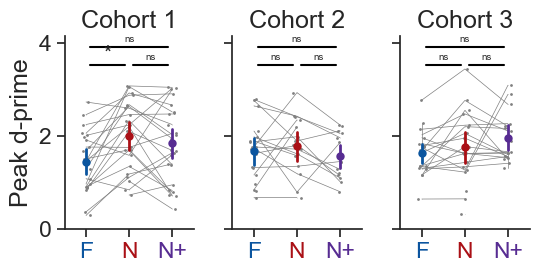

In [201]:
metric = 'max_dprime_engaged'
ylabel = 'Peak d-prime'
ylims = (0, 3.5)
# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()
stats = stats[stats[metric]>0]
stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
stats = stats[stats.mouse_id.isin(platform_experiments.mouse_id.unique())]

# turn ophys_container_id to mouse_id so that across mouse / container plotting works
stats['ophys_container_id'] = stats['mouse_id']


suffix = '_sdk_platform_experiments'

figsize = (6, 2.5)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
for i, project_code in enumerate(project_codes): 
    title = 'Cohort '+str(i+1)
    tmp = stats[stats.project_code==project_code]

    suffix = '_stim_based_'+project_code

    ax[i] = ppf.plot_behavior_metric_by_experience(tmp, metric, title=title, ylabel=ylabel, ylims=ylims,
                                        best_image=False, show_mice=True, plot_stats=True, stripplot=True, show_ns=True,
                                        save_dir=None, folder='behavior_metrics', suffix=suffix, ax=ax[i])
    ax[i].set_title(title)
fig.subplots_adjust(wspace=0.3)
utils.save_figure(fig, figsize, save_dir, folder, metric + '_cohorts')

##### By cell class

In [106]:
# metric = 'mean_dprime_engaged'

# # metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
# #         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

# stats = behavior_stats_sdk.copy()
# stats = stats[stats[metric]>0]
# stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
# # turn ophys_container_id to mouse_id so that across mouse / container plotting works
# stats['ophys_container_id'] = stats['mouse_id']


# suffix = '_sdk_platform_experiments'

# project_codes = ['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope']

# for p, project_code in enumerate(project_codes): 
#     suptitle = project_code+'\nCohort '+str(p+1)
#     tmp = stats[stats.project_code==project_code]

#     suffix = '_sdk_'+project_code+'_by_cell_class'

#     figsize = (2, 9)
#     fig, ax = plt.subplots(3, 1, figsize=figsize, sharex=True, sharey=False)
#     # stats dataframe to save
#     cell_types = utils.get_cell_types()
#     for i, cell_type in enumerate(cell_types):
#         ct_data = tmp[tmp.cell_type == cell_type]

#         ax[i] = ppf.plot_behavior_metric_by_experience(ct_data, metric, title=cell_type, ylabel='d-prime', ylims=[-0.1, 3],
#                                         best_image=False, show_mice=True, plot_stats=True, stripplot=True, show_ns=True,
#                                         save_dir=None, folder='behavior_metrics', suffix=suffix, ax=ax[i])
#     plt.suptitle(suptitle, x=0.5, y=1)
#     if save_dir:
#         utils.save_figure(fig, figsize, save_dir, 'behavior_metrics', metric + suffix)


#### Stim based metrics

In [203]:
engaged_behavior_stats_stim.keys()

Index(['index', 'behavior_session_id', 'response_latency_count',
       'response_latency_mean', 'response_latency_std', 'response_latency_min',
       'response_latency_25%', 'response_latency_50%', 'response_latency_75%',
       'response_latency_max', 'hit_rate', 'fa_rate',
       'number_of_engaged_go_trials', 'number_of_engaged_hits',
       'number_of_engaged_catch_trials', 'number_of_engaged_false_alarms',
       'fraction_engaged', 'dprime_trial_corrected',
       'dprime_non_trial_corrected', 'ophys_session_id', 'ophys_container_id',
       'mouse_id', 'indicator', 'full_genotype', 'driver_line', 'cre_line',
       'reporter_line', 'sex', 'age_in_days', 'imaging_plane_group_count',
       'project_code', 'session_type', 'session_number', 'image_set',
       'behavior_type', 'experience_level', 'prior_exposures_to_session_type',
       'prior_exposures_to_image_set', 'prior_exposures_to_omissions',
       'date_of_acquisition', 'equipment_name', 'num_depths_per_area',
       'o

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats
stats did not save for response_latency_mean


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats
stats did not save for response_latency_mean


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3334: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3343: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats
stats did not save for response_latency_mean


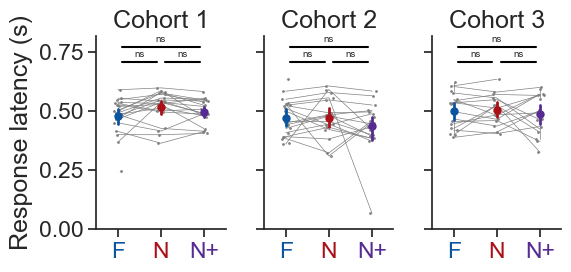

In [210]:
metric = 'response_latency_mean'

# metrics = ['response_latency_mean', 'fraction_engaged',
#         'dprime_trial_corrected', 'hit_rate']

stats = engaged_behavior_stats_stim.copy()
stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# turn ophys_container_id to mouse_id so that across mouse / container plotting works
stats['ophys_container_id'] = stats['mouse_id']


project_codes = ['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope']

figsize = (6, 2.5)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
for i, project_code in enumerate(project_codes): 
    title = 'Cohort '+str(i+1)
    tmp = stats[stats.project_code==project_code]

    suffix = '_stim_based_'+project_code

    ax[i] = ppf.plot_behavior_metric_by_experience(tmp, metric, title=title, ylabel='Response latency (s)', ylims=(0, 0.7),
                                        best_image=False, show_mice=True, plot_stats=True, stripplot=True, show_ns=True,
                                        save_dir=None, folder='behavior_metrics', suffix=suffix, ax=ax[i])
    ax[i].set_title(title)
fig.subplots_adjust(wspace=0.3)
utils.save_figure(fig, figsize, save_dir, folder, metric + '_cohorts')

### Plot behavior by cohort

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3554: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  orient='v', palette=colors, markers='.', ax=ax) # marker_kws={'size':2},
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3561: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats
stats did not save for max_dprime_engaged


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3554: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  orient='v', palette=colors, markers='.', ax=ax) # marker_kws={'size':2},
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3561: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats
stats did not save for max_dprime_engaged


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3554: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  orient='v', palette=colors, markers='.', ax=ax) # marker_kws={'size':2},
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3561: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats
stats did not save for max_dprime_engaged


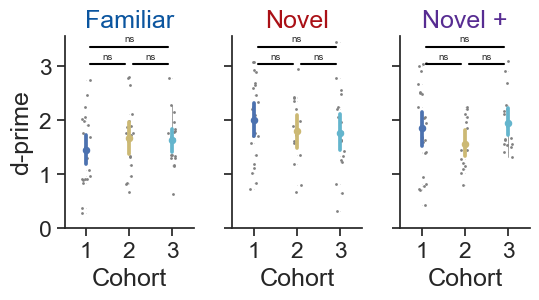

In [215]:
metric = 'max_dprime_engaged'

# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()
stats = stats[stats[metric]>0]
stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
# turn ophys_container_id to mouse_id so that across mouse / container plotting works

# turn ophys_container_id to mouse_id so that across mouse / container plotting works
stats['ophys_container_id'] = stats['mouse_id']

figsize = (6, 2.5)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
for i, experience_level in enumerate(experience_levels): 
# experience_level = experience_levels[0]
    title = experience_level 
    tmp = stats[stats.experience_level==experience_level]

    suffix = '_stim_based_by_chohort_'+experience_level

    ax[i] = ppf.plot_behavior_metric_by_cohort(tmp, metric, title=title, ylabel='D-prime', ylims=(0, 3),
                                        show_containers=True, plot_stats=True, stripplot=True, show_ns=True,
                                        save_dir=None, folder='behavior_metrics', suffix=suffix, ax=ax[i])
    ax[i].set_ylabel('')
ax[0]. set_ylabel('d-prime')
    
fig.subplots_adjust(wspace=0.3)
utils.save_figure(fig, figsize, save_dir, folder, metric + '_cohorts')

In [ ]:
metric = 'response_latency_mean'
ylabel = 'Response latency (s)'
# metrics = ['responsemetric = 'max_dprime_engaged'

# metrics = ['mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged']

stats = behavior_stats_sdk.copy()
stats = stats[stats[metric]>0]
stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]
# turn ophys_container_id to mouse_id so that across mouse / container plotting works

# turn ophys_container_id to mouse_id so that across mouse / container plotting works
stats['ophys_container_id'] = stats['mouse_id']

figsize = (6, 2.5)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
for i, experience_level in enumerate(experience_levels): 
# experience_level = experience_levels[0]
    title = experience_level 
    tmp = stats[stats.experience_level==experience_level]

    suffix = '_stim_based_by_chohort_'+experience_level

    ax[i] = ppf.plot_behavior_metric_by_cohort(tmp, metric, title=title, ylabel=ylabel, ylims=(0, 1),
                                        show_containers=True, plot_stats=True, stripplot=True, show_ns=True,
                                        save_dir=None, folder='behavior_metrics', suffix=suffix, ax=ax[i])
    ax[i].set_ylabel('')
ax[0]. set_ylabel(ylabel)
    
fig.subplots_adjust(wspace=0.3)
utils.save_figure(fig, figsize, save_dir, folder, metric + '_cohorts')

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3554: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  orient='v', palette=colors, markers='.', ax=ax) # marker_kws={'size':2},
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3561: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats
stats did not save for response_latency_mean


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3554: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  orient='v', palette=colors, markers='.', ax=ax) # marker_kws={'size':2},
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3561: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats
stats did not save for response_latency_mean


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3554: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  orient='v', palette=colors, markers='.', ax=ax) # marker_kws={'size':2},
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3561: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats
stats did not save for response_latency_mean


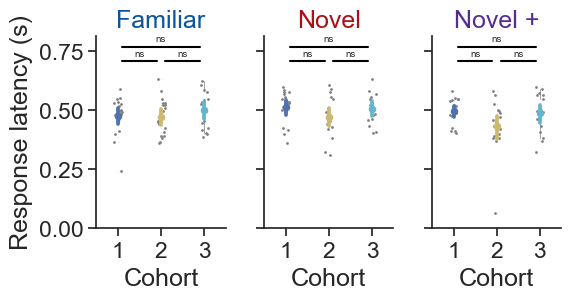

In [220]:
metric = 'response_latency_mean'

# metrics = ['response_latency_mean', 'fraction_engaged',
#         'dprime_trial_corrected', 'hit_rate']

stats = engaged_behavior_stats_stim.copy()
stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# turn ophys_container_id to mouse_id so that across mouse / container plotting works
stats['ophys_container_id'] = stats['mouse_id']

figsize = (6, 2.5)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
for i, experience_level in enumerate(experience_levels): 
# experience_level = experience_levels[0]
    title = experience_level 
    tmp = stats[stats.experience_level==experience_level]

    suffix = '_stim_based_by_chohort_'+experience_level

    ax[i] = ppf.plot_behavior_metric_by_cohort(tmp, metric, title=title, ylabel=ylabel, ylims=(0, 0.7),
                                        show_containers=True, plot_stats=True, stripplot=True, show_ns=True,
                                        save_dir=None, folder='behavior_metrics', suffix=suffix, ax=ax[i])
    ax[i].set_ylabel('')
ax[0]. set_ylabel(ylabel)
    
fig.subplots_adjust(wspace=0.3)
utils.save_figure(fig, figsize, save_dir, folder, metric + '_cohorts')

##### All SDK metrics

In [111]:
# sdk_metrics = ['mean_dprime', 'max_dprime', 'mean_dprime_engaged', 'max_dprime_engaged',
#         'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged', 'engaged_trial_count_x']

# stats = behavior_stats_sdk.copy()

# stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# suffix = '_sdk_platform_experiments'

# for metric in sdk_metrics:
#     ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel=None, ylims=None,
#                                         best_image=False, show_mice=False, plot_stats=True, stripplot=True, show_ns=False,
#                                         save_dir=save_dir, folder='behavior_metrics', suffix=suffix)

#### Stimulus based metric calculation

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3329: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(data=data, x='experience_level', y=metric, order=experience_levels,
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:3337: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xlabel('')


saving_stats


<AxesSubplot:title={'center':'behavior\nperformance'}, ylabel='d-prime'>

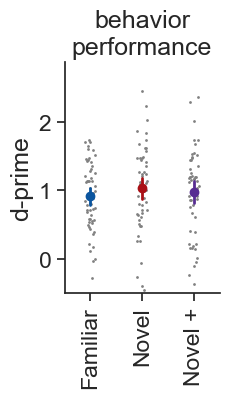

In [112]:
metric = 'dprime_trial_corrected'

stats = engaged_behavior_stats_stim.copy()
stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

suffix = '_stim_based_platform_ophys_experiments'

ppf.plot_behavior_metric_by_experience(stats, metric, title='behavior\nperformance', ylabel='d-prime', ylims=[-0.5, 2.5],
                                       best_image=False, show_mice=False, plot_stats=True,
                                       save_dir=save_dir, folder='behavior_metrics', suffix=suffix)

##### All metrics for stim based

In [113]:
# stim_based_metrics = ['response_latency_mean', 'hit_rate', 'fa_rate',
#          'fraction_engaged', 'dprime_trial_corrected','dprime_non_trial_corrected']

# stats = engaged_behavior_stats_stim.copy()
# stats = stats[stats.behavior_session_id.isin(platform_experiments.behavior_session_id.unique())]

# suffix = '_stim_based_platform_ophys_experiments'

# for metric in stim_based_metrics: 
#     ppf.plot_behavior_metric_by_experience(stats, metric, title='', ylabel=None, ylims=None,
#                                         best_image=False, show-mice=False, plot_stats=True,
#                                         save_dir=save_dir, folder='behavior_metrics', suffix=suffix)

### Plot performace across training stages

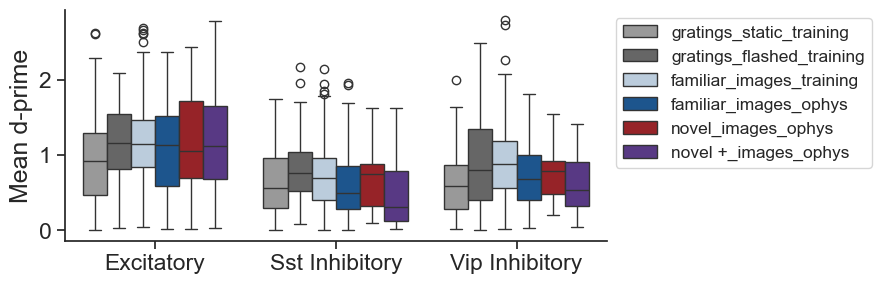

In [114]:
# mean d-prime
data = behavior_stats_sdk.copy()
metric = 'mean_dprime'
data = data[data[metric]>0]

ppf.plot_behavior_metric_across_stages(data, metric, ylabel='Mean d-prime', save_dir=None, folder='behavior_metrics', suffix='_sdk')

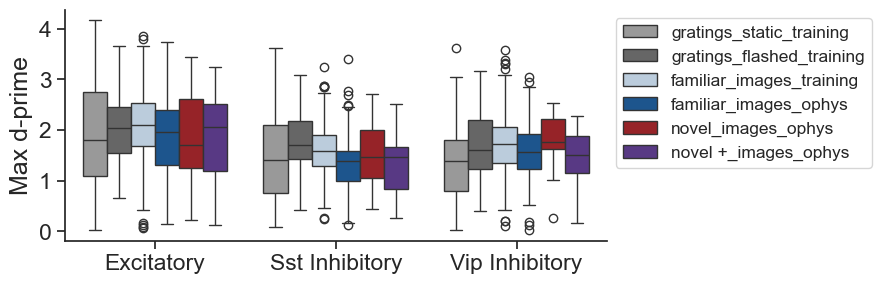

In [115]:
data = behavior_stats_sdk.copy()
metric = 'max_dprime'
data = data[data[metric]>0]

ppf.plot_behavior_metric_across_stages(data, metric, ylabel='Max d-prime', 
                                       save_dir=None, folder='behavior_metrics', suffix='_sdk')

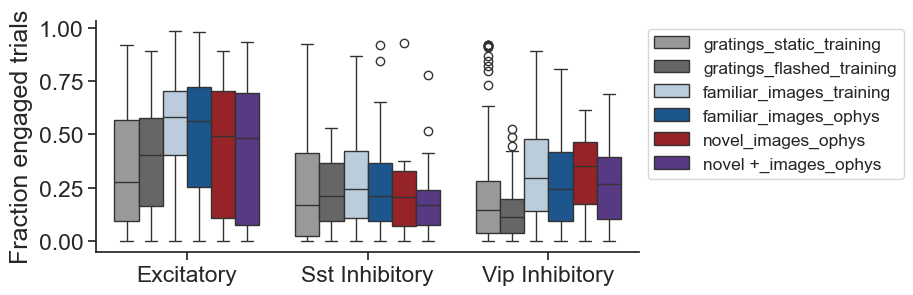

In [116]:
# fraction trials engaged

behavior_stats_sdk['fraction_trials_engaged'] = behavior_stats_sdk.engaged_trial_count_x / behavior_stats_sdk.trial_count_x

data = behavior_stats_sdk.copy()

metric = 'fraction_trials_engaged'

ppf.plot_behavior_metric_across_stages(data, metric, ylabel='Fraction engaged trials', 
                                       save_dir=None, folder='behavior_metrics', suffix='_sdk')

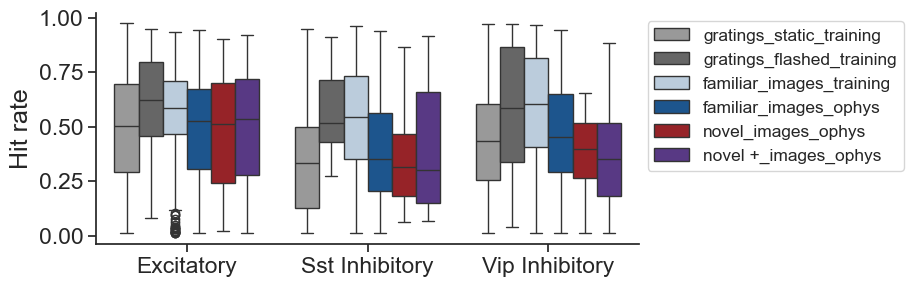

In [117]:
# hit rate

data = behavior_stats_sdk.copy()
metric = 'mean_hit_rate'

ppf.plot_behavior_metric_across_stages(data, metric, ylabel='Hit rate', save_dir=None, folder='behavior_metrics', suffix='_sdk')

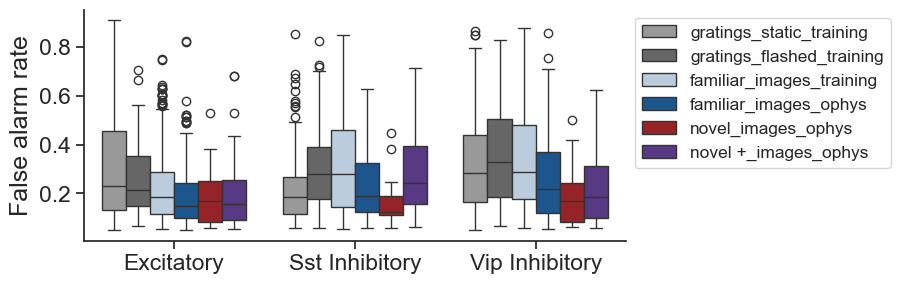

In [118]:
# False alarm rate

data = behavior_stats_sdk.copy()
metric = 'mean_false_alarm_rate'

ppf.plot_behavior_metric_across_stages(data, metric, ylabel='False alarm rate', save_dir=None, folder='behavior_metrics', suffix='_sdk')

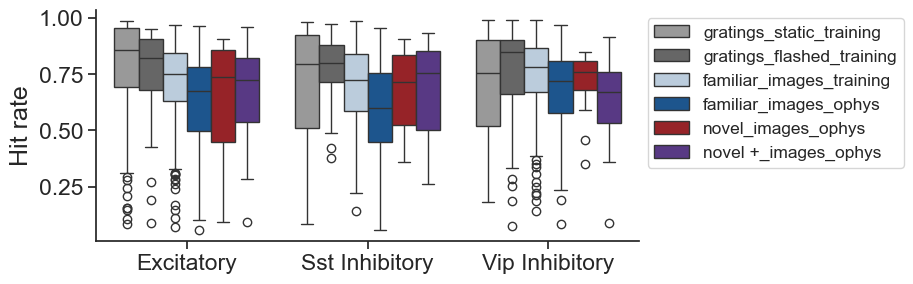

In [119]:
# Hit rate engaged

data = behavior_stats_sdk.copy()
metric = 'mean_hit_rate_engaged'

ppf.plot_behavior_metric_across_stages(data, metric, ylabel='Hit rate', 
                                   save_dir=None, folder='behavior_metrics', suffix='_sdk_engaged')

### Plot familiar and novel images 

#### Lick rasters

In [120]:

# familiar 
familiar_experiment_id = platform_experiments[(platform_experiments.project_code=='VisualBehavior')&
                                        (platform_experiments.experience_level=='Familiar')].index.values[0]
dataset = loading.get_ophys_dataset(familiar_experiment_id)


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [121]:

# def plot_lick_raster_for_trials(trials, title='', save_dir=None, suffix='', ax=None):
#     # trials = dataset.trials
#     # image_set = dataset.metadata.session_type.values[0][-1]
#     # mouse_id = str(dataset.metadata.donor_id.values[0])
#     if ax is None:
#         figsize = (4, 5)
#         fig, ax = plt.subplots(figsize=figsize)
#     for trial in range(len(trials)):
#         trial_data = trials.iloc[trial]
#         trial_start = trial_data.start_time - trial_data.change_time
#         # plot trial
#         if trial_data.go == True: 
#             color = sns.color_palette()[0]
#         else: 
#             color = 'white'
#         ax.axhspan(trial, trial + 1, -200, 200, color='white', alpha=0.075*1.5)     
#         # plot lines in between trials      
#         ax.vlines(trial_start, trial, trial + 1, color='gray', linewidth=0.5, alpha=0.5)
#         # plot line at trial start
#         # ax.vlines(0, trial, trial + 1, color='gray', linewidth=1, linestyle='--')
#         # plot licks 
#         lick_times = [(t - trial_data.change_time) for t in trial_data.lick_times]
#         if len(lick_times) > 0:
#             ax.vlines(lick_times, trial, trial + 1, color='k', linewidth=1)
#             # rewarded lick is a different color
#             ax.vlines(lick_times[0], trial, trial + 1, color='b', linewidth=1)
#         # plot rewards
#         # if np.isnan(trial_data.reward_time) == False:
#         #     reward_time = trial_data.reward_time - trial_data.change_time
#         #     ax.plot(reward_time, trial + 0.5, '^', color='blue', label='reward', markersize=3)
#     # plot reward window 
#     color = sns.color_palette()[0]
#     ax.axvspan(0.15, 0.75, facecolor=color, alpha=.4, edgecolor='none')
#     ax.grid(False)
#     ax.set_ylim(0, len(trials))
#     ax.set_xlim([-1, 5])
#     ax.set_ylabel('Trial number')
#     ax.set_xlabel('Time from change (sec)')
#     ax.set_xticks(np.arange(0, 5, 2))
#     # ax.set_title('M'+mouse_id+' image set '+image_set, fontsize=14)
#     ax.set_title(title, fontsize=16)
#     ax.invert_yaxis()
#     # plt.gca().invert_yaxis()
#     plt.subplots_adjust(left=0.3)
#     if save_dir:
#         metadata_string = utils.get_metadata_string(dataset.metadata)
#         utils.save_figure(fig, figsize, save_dir, 'lick_rasters', metadata_string+suffix)
#     return ax


<AxesSubplot:xlabel='Time from change (sec)', ylabel='Trial number'>

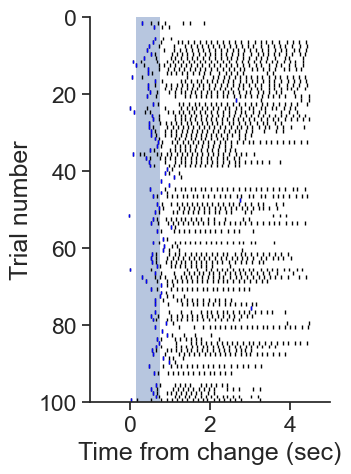

In [122]:
trials = dataset.trials.copy()
trials = trials[trials.go==True]
filename = utils.get_metadata_string(dataset.metadata)
ppf.plot_lick_raster_for_trials(trials, title='', save_dir=save_dir, suffix='', filename=filename, ax=None)

In [123]:
mouse_id = 512458
mouse_id = 425496

# familiar 
familiar_experiment_id = platform_experiments[(platform_experiments.mouse_id==mouse_id)&
                                        (platform_experiments.experience_level=='Familiar')].index.values[0]
familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

# novel for same mouse 
novel_experiment_id = platform_experiments[(platform_experiments.experience_level=='Novel') & 
                                        (platform_experiments.mouse_id==mouse_id)].index.values[0]
print(novel_experiment_id)
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


808621034


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


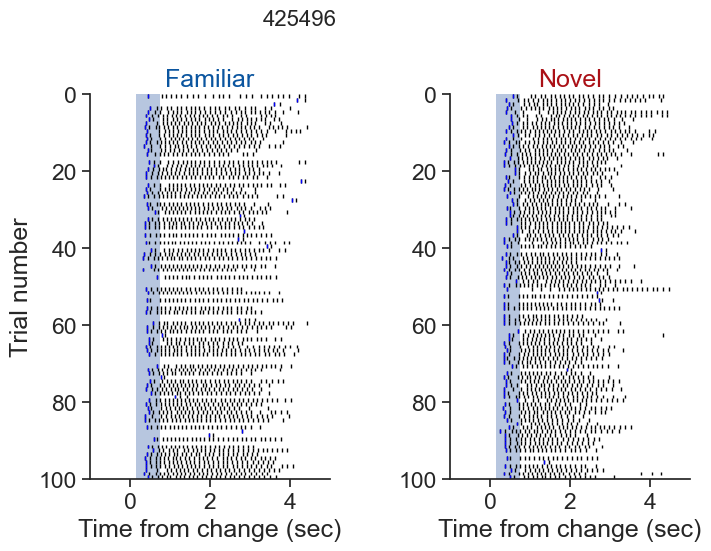

In [124]:
colors = utils.get_experience_level_colors()

figsize = (10, 5)
fig, ax = plt.subplots(1, 2, figsize=figsize, sharey=False)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go==True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', save_dir=None, suffix='_familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])

trials = novel_dataset.trials.copy()
trials = trials[trials.go==True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', save_dir=None, suffix='_novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')

plt.subplots_adjust(wspace=0.5)
plt.suptitle(mouse_id, x=0.51, y=1.05, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id)+'_F_N_example_fig')

#### add novel +

In [125]:
# novel + for same mouse 
novel_plus_experiment_id = platform_experiments[(platform_experiments.experience_level=='Novel +') & 
                                        (platform_experiments.mouse_id==mouse_id)].index.values[0]
print(novel_plus_experiment_id)
novel_plus_dataset = loading.get_ophys_dataset(novel_plus_experiment_id)

809501118


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


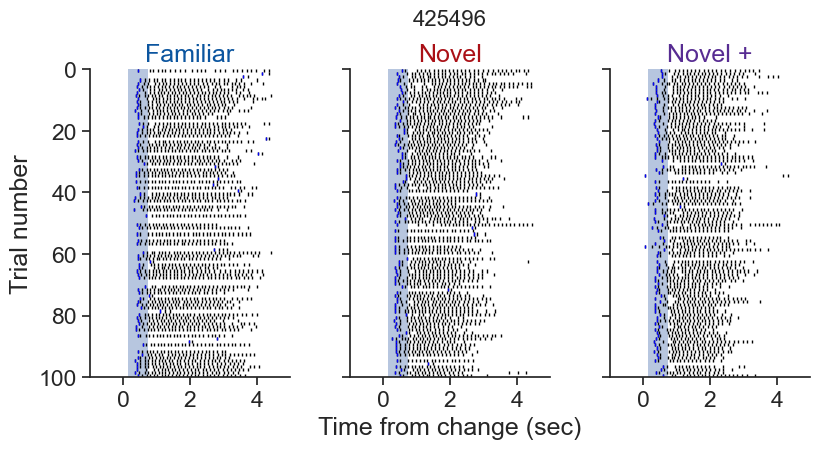

In [126]:
colors = utils.get_experience_level_colors()

figsize = (12, 4)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)

trials = familiar_dataset.trials.copy()
trials = trials[trials.go==True]
trials = trials[:100]
ax[0] = ppf.plot_lick_raster_for_trials(trials, title='Familiar', save_dir=None, suffix='_familiar', ax=ax[0])
ax[0].set_title('Familiar', color=colors[0])
ax[0].set_xlabel('')

trials = novel_dataset.trials.copy()
trials = trials[trials.go==True]
trials = trials[:100]
ax[1] = ppf.plot_lick_raster_for_trials(trials, title='Novel', save_dir=None, suffix='_novel', ax=ax[1])
ax[1].set_title('Novel', color=colors[1])
ax[1].set_ylabel('')


trials = novel_plus_dataset.trials.copy()
trials = trials[trials.go==True]
trials = trials[:100]
ax[2] = ppf.plot_lick_raster_for_trials(trials, title='Novel +', save_dir=None, suffix='_novel_plus', ax=ax[2])
ax[2].set_title('Novel +', color=colors[2])
ax[2].set_ylabel('')
ax[2].set_xlabel('')


plt.subplots_adjust(wspace=0.3)
plt.suptitle(mouse_id, x=0.6, y=1.03, fontsize=16)
utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id)+'_F_N_N+_example_fig')

#### plot for all mice

In [127]:
# for mouse_id in platform_experiments.mouse_id.unique(): 
#     # familiar 
#     familiar_experiment_id = platform_experiments[(platform_experiments.mouse_id==mouse_id)&
#                                             (platform_experiments.experience_level=='Familiar')].index.values[0]
#     familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

#     # novel for same mouse 
#     novel_experiment_id = platform_experiments[(platform_experiments.experience_level=='Novel') & 
#                                             (platform_experiments.mouse_id==mouse_id)].index.values[0]
#     novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

#     colors = utils.get_experience_level_colors()

#     figsize = (10, 5)
#     fig, ax = plt.subplots(1, 2, figsize=figsize, sharey=False)

#     trials = familiar_dataset.trials.copy()
#     trials = trials[trials.go==True]
#     ax[0] = plot_lick_raster_for_trials(trials, title='Familiar', save_dir=None, suffix='_familiar', ax=ax[0])
#     ax[0].set_title('Familiar', color=colors[0])

#     trials = novel_dataset.trials.copy()
#     trials = trials[trials.go==True]
#     ax[1] = plot_lick_raster_for_trials(trials, title='Novel', save_dir=None, suffix='_novel', ax=ax[1])
#     ax[1].set_title('Novel', color=colors[1])
#     ax[1].set_ylabel('')

#     plt.subplots_adjust(wspace=0.5)
#     plt.suptitle(str(mouse_id), x=0.5, y=1.05)
#     utils.save_figure(fig, figsize, save_dir, 'lick_rasters', str(mouse_id)+'_F_N')

#### Images without experience colors

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


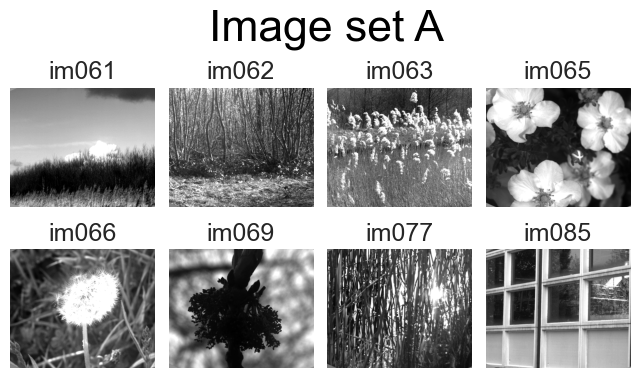

In [128]:

# familiar 
familiar_experiment_id = platform_experiments[(platform_experiments.project_code=='VisualBehavior')&
                                        (platform_experiments.experience_level=='Familiar')].index.values[0]
familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

stimulus_templates = familiar_dataset.stimulus_templates.copy()

figsize = (8, 4)
fig, ax = plt.subplots(2, 4, figsize=figsize)
ax=ax.ravel()
for i,image_name in enumerate(np.sort(stimulus_templates.index)):
    image = stimulus_templates.loc[image_name]['unwarped'].copy()
    image[np.isnan(image)] = 150
    ax[i].imshow(image, cmap='gray')
    ax[i].set_title(image_name,)
    ax[i].set_xlim(480, 1400)
    ax[i].set_ylim(220, 980)
    ax[i].invert_yaxis()
    ax[i].axis('off')
    
# fig.suptitle('Familiar Training Set\nimage set A', color=colors[0])
fig.suptitle('Image set A', x=0.52, y=1.04,  color='k', fontsize=32)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

utils.save_figure(fig, figsize, save_dir, 'image_sets', 'image_set_A')

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


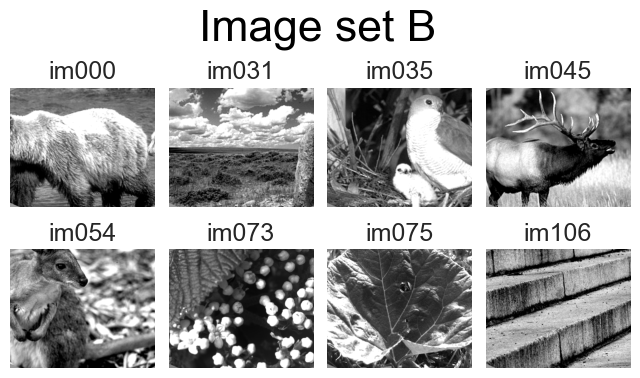

In [129]:

# novel 
novel_experiment_id = platform_experiments[(platform_experiments.project_code=='VisualBehavior')&
                                           (platform_experiments.experience_level=='Novel')].index.values[0]
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

stimulus_templates = novel_dataset.stimulus_templates.copy()

figsize = (8, 4)
fig, ax = plt.subplots(2, 4, figsize=figsize)
ax=ax.ravel()
for i,image_name in enumerate(np.sort(stimulus_templates.index)):
    image = stimulus_templates.loc[image_name]['unwarped'].copy()
    image[np.isnan(image)] = 150
    ax[i].imshow(image, cmap='gray')
    ax[i].set_title(image_name,)
    ax[i].set_xlim(480, 1400)
    ax[i].set_ylim(220, 980)
    ax[i].invert_yaxis()
    ax[i].axis('off')
    
# fig.suptitle('Familiar Training Set\nimage set A', color=colors[0])
fig.suptitle('Image set B', x=0.51, y=1.04,  color='k', fontsize=32)
plt.subplots_adjust(hspace=0.1, wspace=0.1)
utils.save_figure(fig, figsize, save_dir, 'image_sets', 'image_set_B')

#### With experience colors

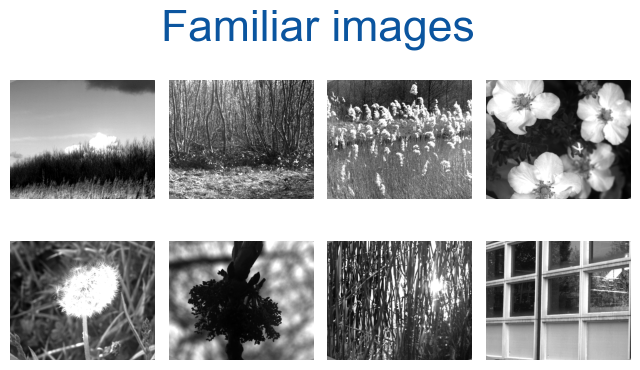

In [130]:
# familiar 
# familiar_experiment_id = platform_experiments[(platform_experiments.project_code=='VisualBehavior')&
#                                         (platform_experiments.experience_level=='Familiar')].index.values[0]
# familiar_dataset = loading.get_ophys_dataset(familiar_experiment_id)

stimulus_templates = familiar_dataset.stimulus_templates.copy()

figsize = (8, 4)
fig, ax = plt.subplots(2, 4, figsize=figsize)
ax=ax.ravel()
for i,image_name in enumerate(np.sort(stimulus_templates.index)):
    image = stimulus_templates.loc[image_name]['unwarped'].copy()
    image[np.isnan(image)] = 150
    ax[i].imshow(image, cmap='gray')
    # ax[i].set_title(image_name, fontsize=14)
    ax[i].set_xlim(480, 1400)
    ax[i].set_ylim(220, 980)
    ax[i].invert_yaxis()
    ax[i].axis('off')
    
# fig.suptitle('Familiar Training Set\nimage set A', color=colors[0])
fig.suptitle('Familiar images', x=0.51, y=1.02,  color=colors[0], fontsize=32)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

utils.save_figure(fig, figsize, save_dir, 'image_sets', 'Familiar_images')


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


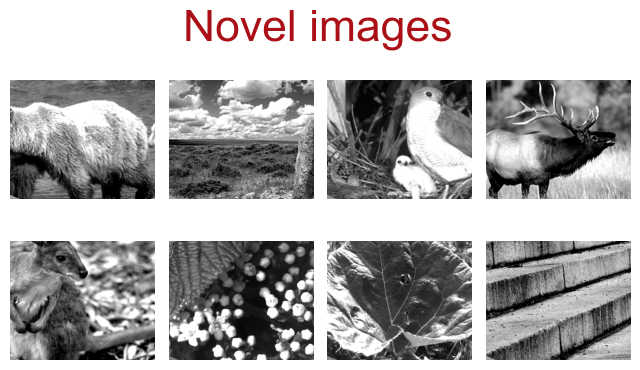

In [131]:
# for A/B

# novel 
novel_experiment_id = platform_experiments[(platform_experiments.project_code=='VisualBehavior')&
                                           (platform_experiments.experience_level=='Novel')].index.values[0]
novel_dataset = loading.get_ophys_dataset(novel_experiment_id)

stimulus_templates = novel_dataset.stimulus_templates.copy()

figsize = (8, 4)
fig, ax = plt.subplots(2, 4, figsize=figsize)
ax=ax.ravel()
for i,image_name in enumerate(np.sort(stimulus_templates.index)):
    image = stimulus_templates.loc[image_name]['unwarped'].copy()
    image[np.isnan(image)] = 150
    ax[i].imshow(image, cmap='gray')
    ax[i].set_xlim(480, 1400)
    ax[i].set_ylim(220, 980)
    ax[i].invert_yaxis()
    ax[i].axis('off')
    
# fig.suptitle('Familiar Training Set\nimage set A', color=colors[0])
fig.suptitle('Novel images', x=0.51, y=1.02,  color=colors[1], fontsize=32)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

utils.save_figure(fig, figsize, save_dir, 'image_sets', 'Novel_images')


### Ophys session sequence 

#### Ignoring image set identity - Familiar is always blue

In [19]:
utils.get_ophys_stage_color_map(as_rgb=True)

{'familiar_images_in_dataset': array([ 11,  85, 159], dtype=uint8),
 'familiar_images': array([108, 153, 197], dtype=uint8),
 'familiar_images_passive': array([157, 187, 216], dtype=uint8),
 'novel_images_first_novel_in_dataset': array([169,  16,  22], dtype=uint8),
 'novel +_images_in_dataset': array([ 86,  44, 145], dtype=uint8),
 'novel +_images': array([154, 128, 189], dtype=uint8),
 'novel +_images_passive': array([187, 170, 211], dtype=uint8)}

In [35]:
behavior_sessions.experience_level.unique()

array(['Training', 'Familiar', 'Novel', 'Novel +'], dtype=object)

In [36]:
platform_experiments.experience_level.unique()

array(['Familiar', 'Novel', 'Novel +'], dtype=object)

In [37]:
behavior_sessions = utilities.add_stimulus_experience_level_to_behavior_sessions(behavior_sessions)
behavior_sessions.stimulus_experience_level.unique()

array(['gratings_static', 'gratings_flashed', 'familiar_images',
       'novel_images', 'novel +_images'], dtype=object)

#### For full dataset

In [55]:
# all_behavior_sessions = behavior_sessions.copy()

# make fake ophys_container_id column so the below functions will work
all_behavior_sessions['ophys_container_id'] = all_behavior_sessions.mouse_id.values
# add last familiar and first novel columns
all_behavior_sessions = utilities.add_passive_flag_to_ophys_experiment_table(all_behavior_sessions)
all_behavior_sessions = utilities.add_has_ophys_column_to_behavior_sessions(all_behavior_sessions)

all_behavior_sessions = utilities.add_date_string(all_behavior_sessions)
all_behavior_sessions = utilities.add_n_relative_to_first_novel_column(all_behavior_sessions)
all_behavior_sessions = utilities.add_first_novel_column(all_behavior_sessions)
all_behavior_sessions = utilities.add_second_novel_active_column(all_behavior_sessions)
all_behavior_sessions = utilities.add_last_familiar_active_column(all_behavior_sessions)

In [57]:
all_behavior_sessions = utilities.add_ophys_stage_to_behavior_sessions(all_experiments_table, all_behavior_sessions)


1936


In [63]:
all_behavior_sessions.ophys_stage.unique()

array(['None', 'familiar_images', 'familiar_images_in_dataset',
       'familiar_images_passive', 'familiar_images_passive_in_dataset',
       'novel_images_first_novel', 'novel +_images',
       'novel +_images_passive', 'novel +_images_in_dataset',
       'novel +_images_passive_in_dataset',
       'novel_images_first_novel_in_dataset',
       'novel_images_first_novel_passive'], dtype=object)

1936


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Ophys session sequence'}, xlabel='Ophys session number', ylabel='Mouse number'>

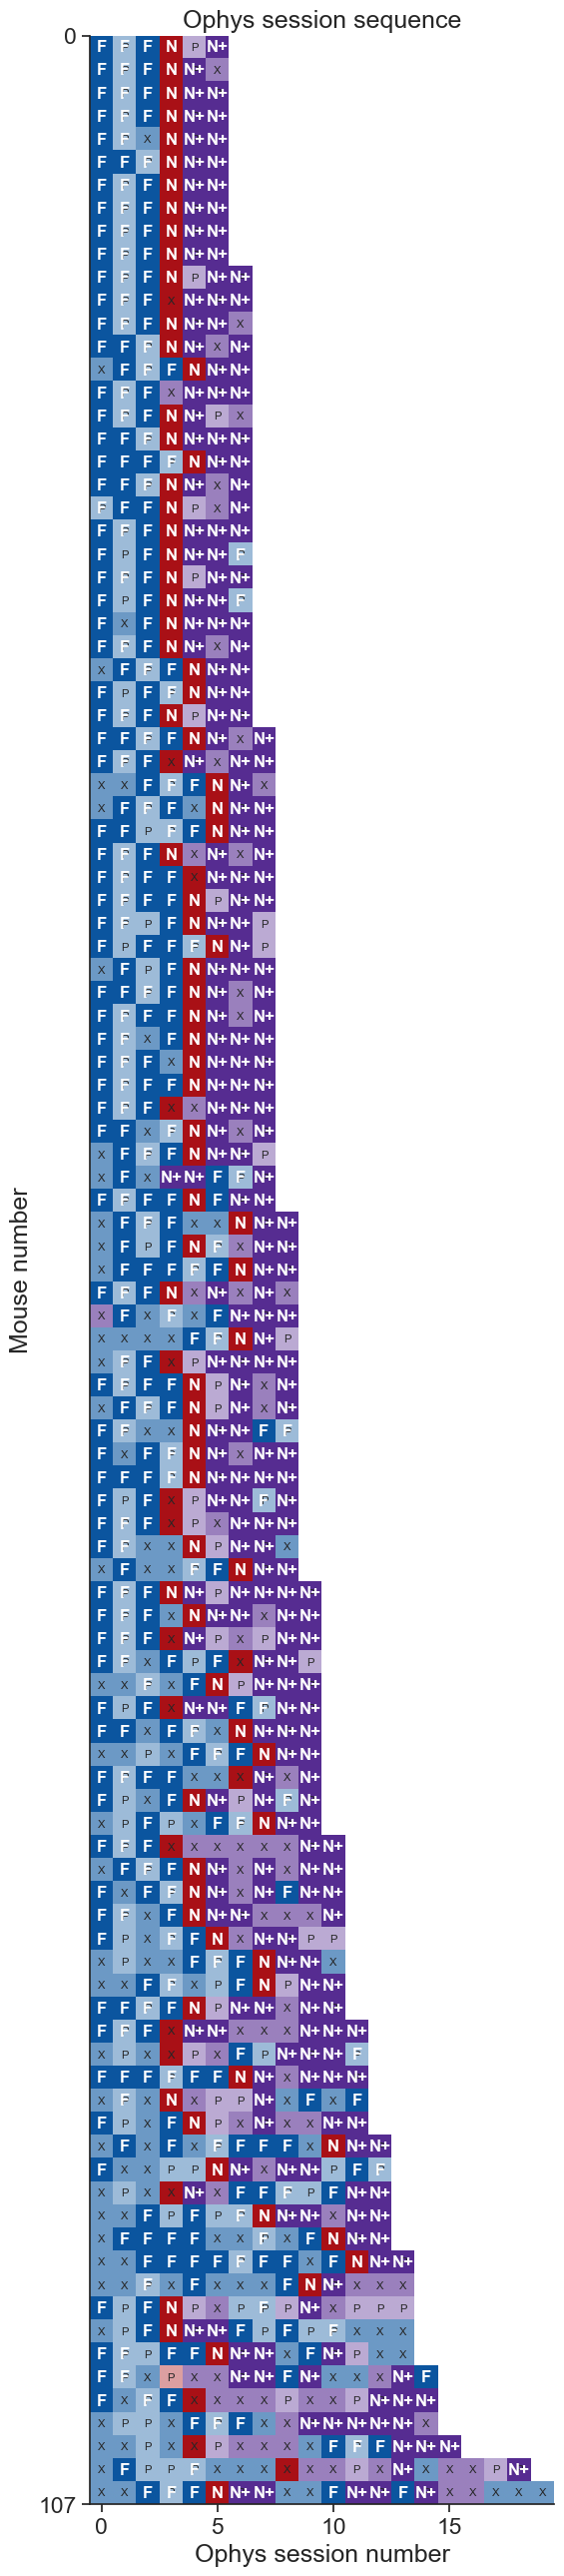

In [65]:
# including 4x2

all_behavior_sessions = utilities.add_ophys_stage_to_behavior_sessions(all_experiments_table, all_behavior_sessions)

color_column = 'ophys_stage'
color_map = utils.get_ophys_stage_color_map(as_rgb=True)
# color_map = utils.get_behavior_stage_color_map(as_rgb=True)

sessions = all_behavior_sessions.copy()
# exclude non-ophys & habituation sessions, which have ophys_stage = None
sessions = sessions[sessions.ophys_stage!='None']
# exclude mice that are not in platform paper dataset 
# sessions = sessions[sessions.mouse_id.isin(platform_experiments.mouse_id.unique())]

ppf.plot_ophys_history_for_mice(sessions, color_column=color_column, color_map=color_map, save_dir=save_dir, 
                                label_with_mouse_id=False, suffix='_all_mice')

1936


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Ophys session sequence'}, xlabel='Ophys session number', ylabel='Mouse number'>

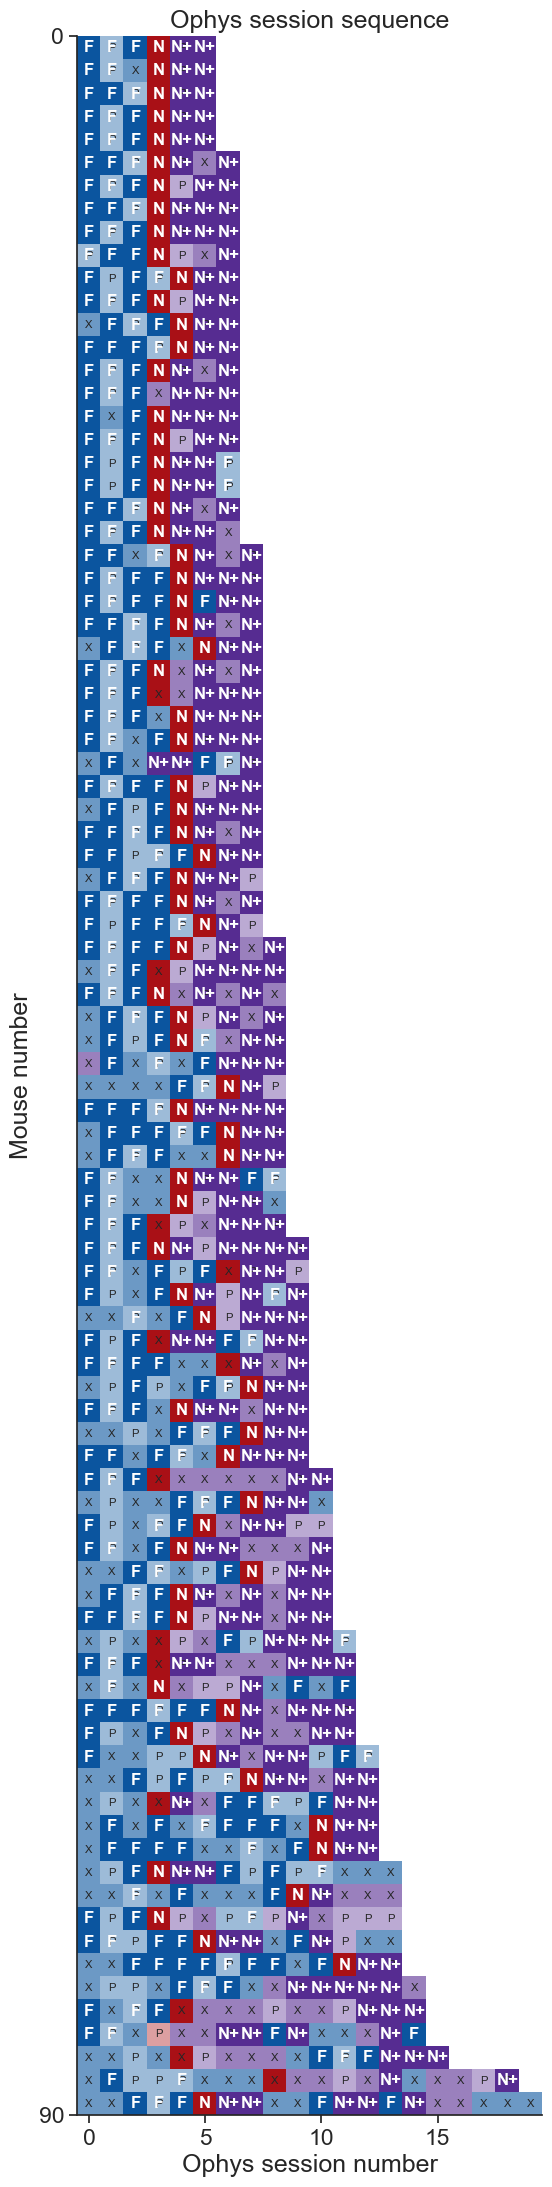

In [66]:
# without 4x2

# including 4x2

all_behavior_sessions = utilities.add_ophys_stage_to_behavior_sessions(all_experiments_table, all_behavior_sessions)

all_behavior_sessions = all_behavior_sessions[all_behavior_sessions.project_code!='VisualBehaviorMultiscope4areasx2d']

color_column = 'ophys_stage'
color_map = utils.get_ophys_stage_color_map(as_rgb=True)
# color_map = utils.get_behavior_stage_color_map(as_rgb=True)

sessions = all_behavior_sessions.copy()
# exclude non-ophys & habituation sessions, which have ophys_stage = None
sessions = sessions[sessions.ophys_stage!='None']
# exclude mice that are not in platform paper dataset 
# sessions = sessions[sessions.mouse_id.isin(platform_experiments.mouse_id.unique())]

ppf.plot_ophys_history_for_mice(sessions, color_column=color_column, color_map=color_map, save_dir=save_dir, 
                                label_with_mouse_id=False, suffix='_all_mice')

In [ ]:
# per cohort

#### For platform dataset

In [33]:
color_map

{'gratings_static_training': array([153, 153, 153], dtype=uint8),
 'gratings_flashed_training': array([102, 102, 102], dtype=uint8),
 'familiar_images_training': array([181, 204, 226], dtype=uint8),
 'familiar_images_ophys': array([ 11,  85, 159], dtype=uint8),
 'familiar_images_ophys_passive': array([108, 153, 197], dtype=uint8),
 'novel_images_ophys': array([169,  16,  22], dtype=uint8),
 'novel_images_ophys_passive': array([154, 128, 189], dtype=uint8),
 'novel +_images_ophys': array([ 86,  44, 145], dtype=uint8),
 'novel +_images_ophys_passive': array([154, 128, 189], dtype=uint8)}

In [42]:
behavior_sessions.experience_level.unique()

array(['Training', 'Familiar', 'Novel', 'Novel +'], dtype=object)

In [39]:
behavior_sessions.ophys_stage.unique()

array(['None', 'familiar_images', 'familiar_images_passive',
       'familiar_images_in_dataset',
       'novel 1_images_first_novel_in_dataset', 'novel >1_images_passive',
       'novel >1_images_in_dataset', 'novel >1_images'], dtype=object)

In [43]:
behavior_sessions.stimulus_experience_level.unique()

array(['gratings_static', 'gratings_flashed', 'familiar_images',
       'novel_images', 'novel +_images'], dtype=object)

In [46]:
behavior_sessions.ophys_stage.unique()

array(['None', 'familiar_images', 'familiar_images_passive',
       'familiar_images_in_dataset',
       'novel_images_first_novel_in_dataset', 'novel +_images_passive',
       'novel +_images_in_dataset', 'novel +_images'], dtype=object)

402


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Ophys session sequence'}, xlabel='Ophys session number', ylabel='Mouse number'>

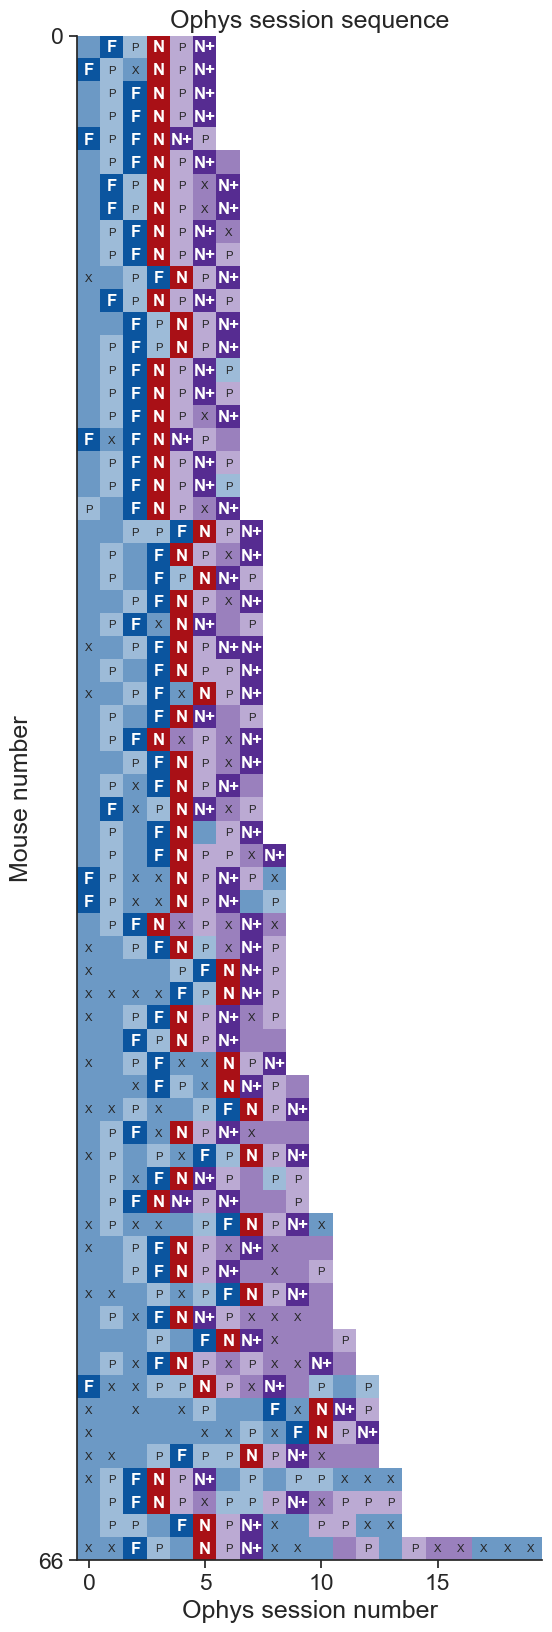

In [47]:
behavior_sessions = utilities.add_ophys_stage_to_behavior_sessions(platform_experiments, behavior_sessions)

color_column = 'ophys_stage'
color_map = utils.get_ophys_stage_color_map(as_rgb=True)
# color_map = utils.get_behavior_stage_color_map(as_rgb=True)

sessions = behavior_sessions.copy()
# exclude non-ophys & habituation sessions, which have ophys_stage = None
sessions = sessions[sessions.ophys_stage!='None']
# exclude mice that are not in platform paper dataset 
sessions = sessions[sessions.mouse_id.isin(platform_experiments.mouse_id.unique())]

ppf.plot_ophys_history_for_mice(sessions, color_column=color_column, color_map=color_map, save_dir=save_dir, 
                                label_with_mouse_id=False, suffix='_all_mice')

399


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Ophys session sequence'}, xlabel='Ophys session number', ylabel='Mouse number'>

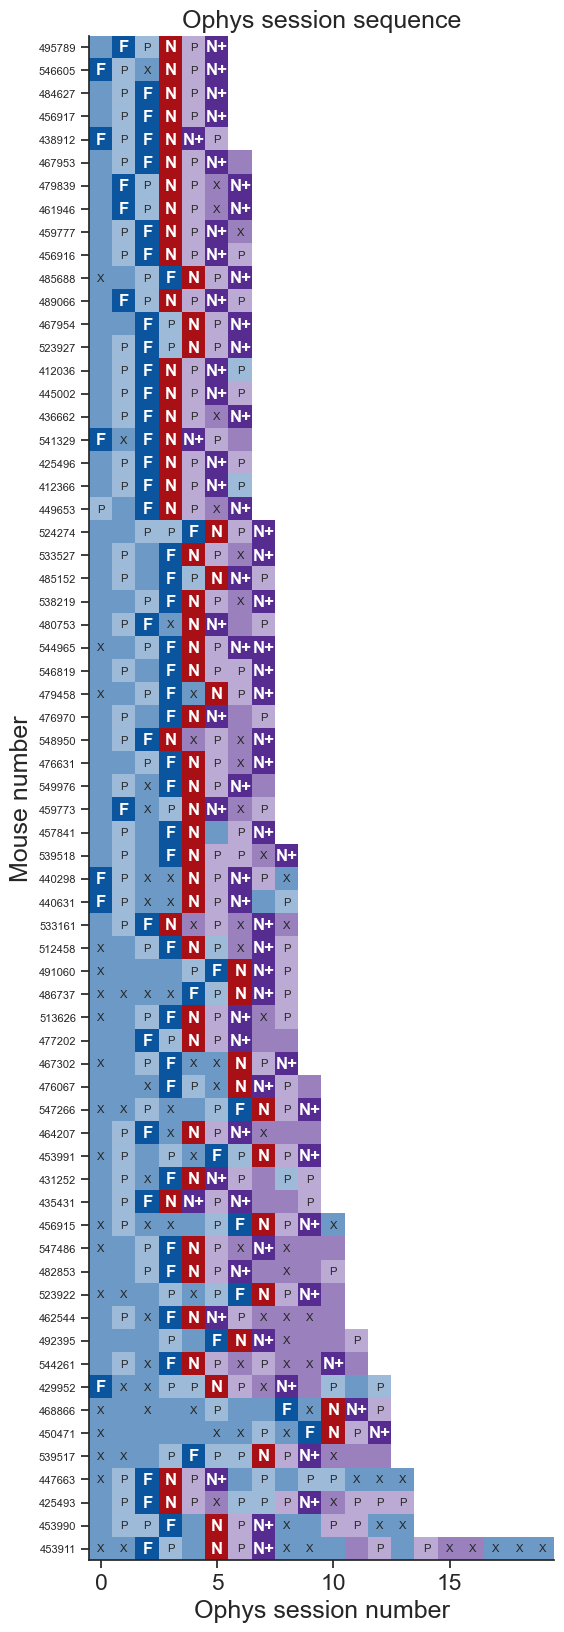

In [181]:
behavior_sessions = utilities.add_ophys_stage_to_behavior_sessions(platform_experiments, behavior_sessions)

color_column = 'ophys_stage'
color_map = utils.get_ophys_stage_color_map(as_rgb=True)
# color_map = utils.get_behavior_stage_color_map(as_rgb=True)

sessions = behavior_sessions.copy()
# exclude non-ophys & habituation sessions, which have ophys_stage = None
sessions = sessions[sessions.ophys_stage!='None']
# exclude mice that are not in platform paper dataset 
sessions = sessions[sessions.mouse_id.isin(platform_experiments.mouse_id.unique())]

ppf.plot_ophys_history_for_mice(sessions, color_column=color_column, color_map=color_map, save_dir=save_dir, 
                                label_with_mouse_id=True, suffix='_all_mice')

402


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\data_access\utilities.py:1462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # ophys sessions 1,2,3 = Familiar
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\data_access\utilities.py:1466: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # ophys session 4 with no prior exposures to image set = Novel


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Ophys session types'}, xlabel='Session number', ylabel='Mouse number'>

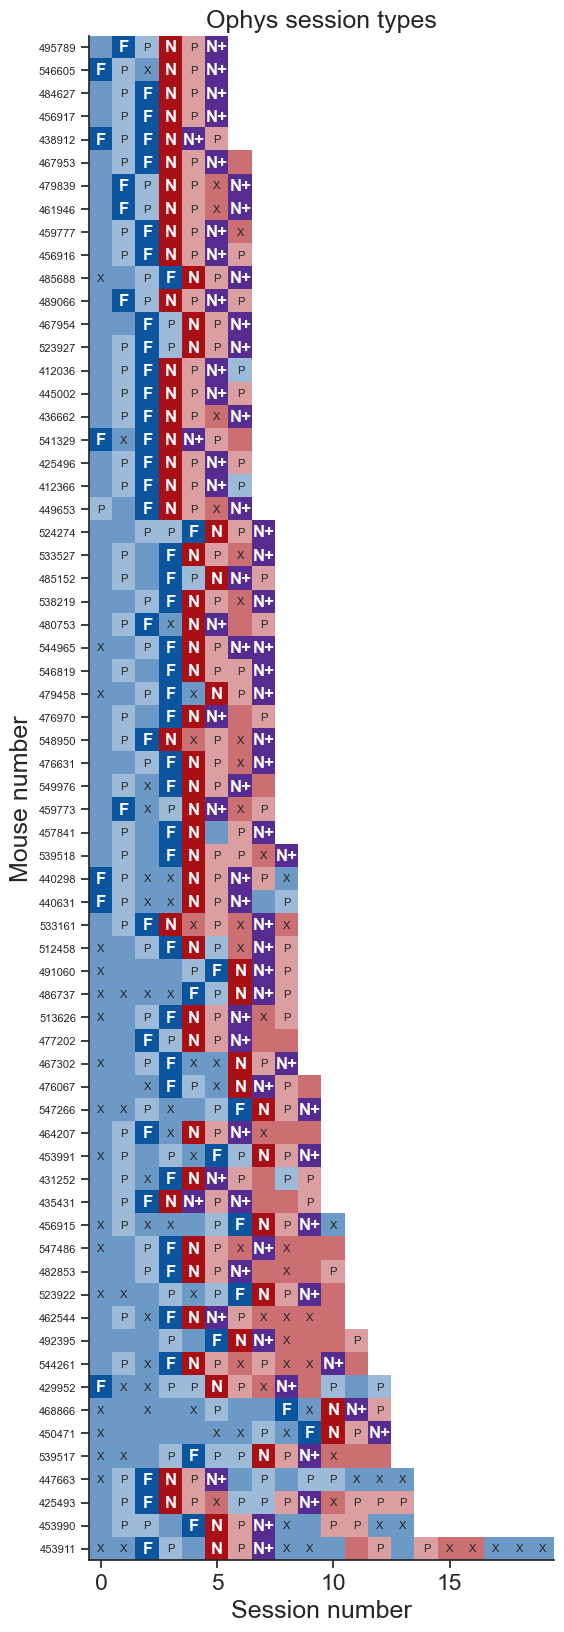

In [ ]:
behavior_sessions = utilities.add_ophys_stage_to_behavior_sessions(platform_experiments, behavior_sessions)

color_column = 'ophys_stage'
color_map = utils.get_ophys_stage_color_map(as_rgb=True)

sessions = behavior_sessions.copy()
# exclude non-ophys & habituation sessions, which have ophys_stage = None
sessions = sessions[sessions.ophys_stage!='None']
# exclude mice that are not in platform paper dataset 
sessions = sessions[sessions.mouse_id.isin(platform_experiments.mouse_id.unique())]

ppf.plot_ophys_history_for_mice(sessions, color_column=color_column, color_map=color_map,
group_by_cre=False, label_rows_by_cre=False, label_with_mouse_id=True, save_dir=None, suffix='_with_mouse_ids')


#### For cohorts separately

Categories
* image set A - active
* image set A - passive
* image set A - active, in dataset
<!-- * image set A - failed QC -->
* image set B - active
* image set B - passive
* image set B - active, in dataset
<!-- * image set B - failed QC -->

In [ ]:
ab_mice = behavior_sessions[behavior_sessions.project_code.isin(['VisualBehaviorMultiscope', 'VisualBehavior'])].mouse_id.unique()
ba_mice = behavior_sessions[behavior_sessions.project_code.isin(['VisualBehaviorTask1B'])].mouse_id.unique()

402


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\data_access\utilities.py:1462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # ophys sessions 1,2,3 = Familiar
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\data_access\utilities.py:1466: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # ophys session 4 with no prior exposures to image set = Novel


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Cohorts 1 & 2'}, xlabel='Session number', ylabel='Mouse number'>

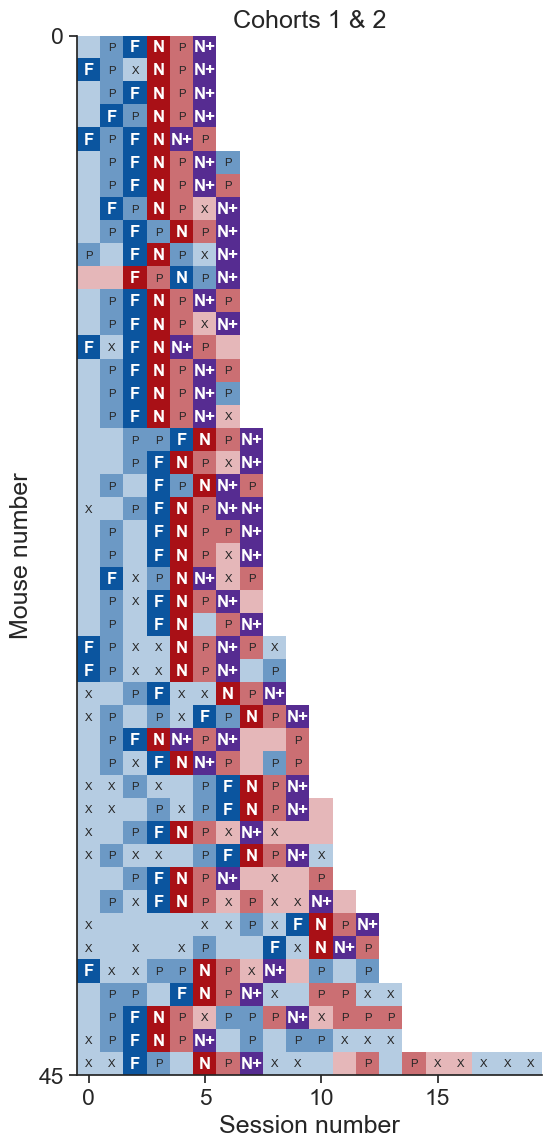

In [ ]:
behavior_sessions = utilities.add_ophys_stage_to_behavior_sessions(platform_experiments, behavior_sessions)

color_column = 'stimulus_phase'
color_map = utils.get_stimulus_phase_color_map(as_rgb=True)

sessions = behavior_sessions[behavior_sessions.mouse_id.isin(ab_mice)]
# exclude non-ophys & habituation sessions, which have ophys_stage = None
sessions = sessions[sessions.ophys_stage!='None']
# exclude mice that are not in platform paper dataset 
sessions = sessions[sessions.mouse_id.isin(platform_experiments.mouse_id.unique())]

ppf.plot_ophys_history_for_mice(sessions, color_column=color_column, color_map=color_map, title='Cohorts 1 & 2')

402


C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\data_access\utilities.py:1462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # ophys sessions 1,2,3 = Familiar
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\data_access\utilities.py:1466: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # ophys session 4 with no prior exposures to image set = Novel


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<AxesSubplot:title={'center':'Cohort 3'}, xlabel='Session number', ylabel='Mouse number'>

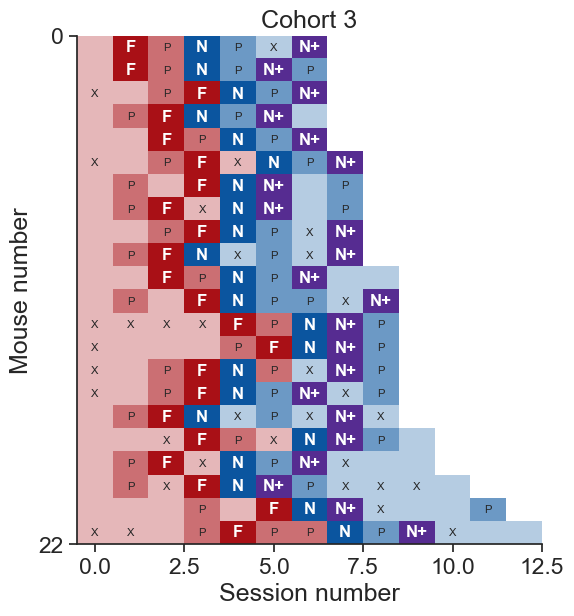

In [ ]:
behavior_sessions = utilities.add_ophys_stage_to_behavior_sessions(platform_experiments, behavior_sessions)

color_column = 'stimulus_phase'
color_map = utils.get_stimulus_phase_color_map(as_rgb=True)

sessions = behavior_sessions[behavior_sessions.mouse_id.isin(ba_mice)]
# exclude non-ophys & habituation sessions, which have ophys_stage = None
sessions = sessions[sessions.ophys_stage!='None']
# exclude mice that are not in platform paper dataset 
sessions = sessions[sessions.mouse_id.isin(platform_experiments.mouse_id.unique())]

ppf.plot_ophys_history_for_mice(sessions, color_column=color_column, color_map=color_map, title='Cohort 3')

### Plot response probability heatmaps across image transitions

66 66


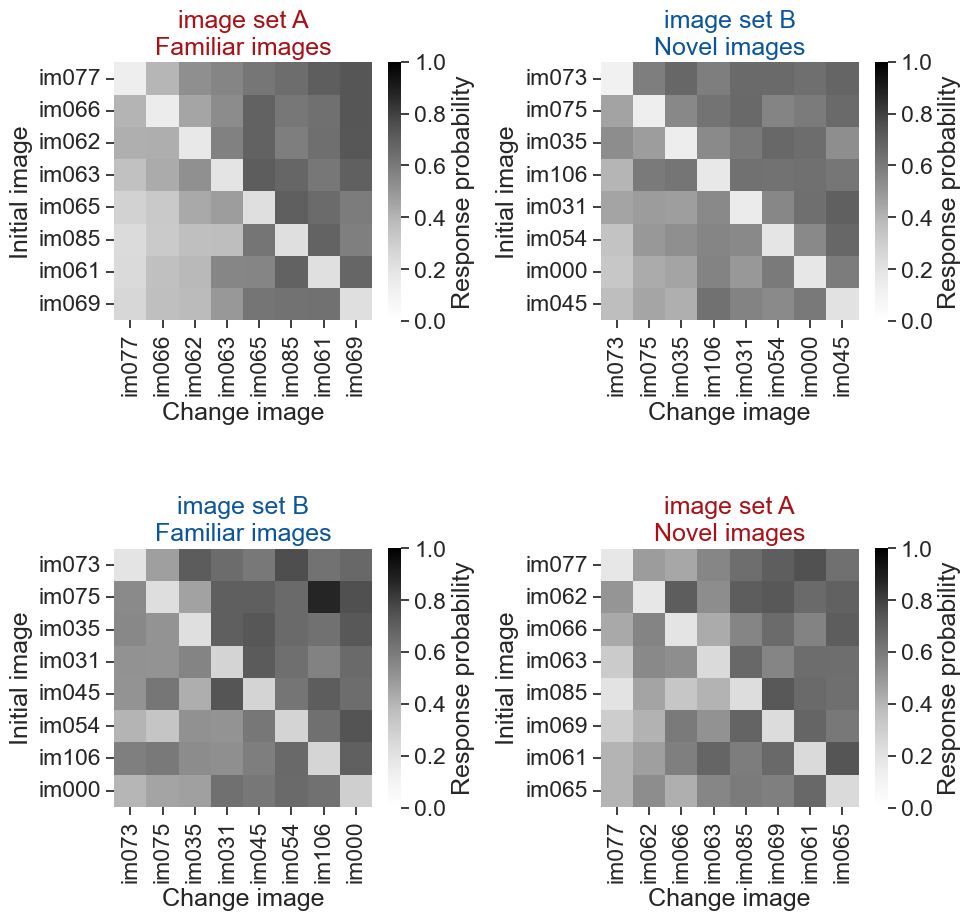

In [ ]:
# limits to engaged portion of session when loading response probability values
ppf.plot_response_probability_heatmaps_for_cohorts(behavior_sessions, save_dir=save_dir)

### Sort and plot performance across all image transitions for A-B mice

In [ ]:
if 'last_familiar_active' not in behavior_sessions.columns:
    # make fake ophys_container_id column so the below functions will work
    behavior_sessions['ophys_container_id'] = behavior_sessions.mouse_id.values
    # add last familiar and first novel columns
    behavior_sessions = utilities.add_date_string(behavior_sessions)
    behavior_sessions = utilities.add_n_relative_to_first_novel_column(behavior_sessions)
    behavior_sessions = utilities.add_first_novel_column(behavior_sessions)
    behavior_sessions = utilities.add_second_novel_active_column(behavior_sessions)
    behavior_sessions = utilities.add_last_familiar_active_column(behavior_sessions)


In [ ]:
def add_image_pair_column(data):
    data = data.reset_index(drop=True)
    data['image_pair'] = [data.iloc[row]['previous_image_name'][2:]+'_'+data.iloc[row]['image_name'][2:] for row in range(len(data))]
    return data

def add_image_pair_index(data, pair_order):
    data['image_pair_index'] = None
    for row in range(len(data)):
        image_pair = data.iloc[row].image_pair
        pairs = list(pair_order)
        index = pairs.index(image_pair)
        data.at[row, 'image_pair_index'] = index
    return data

In [ ]:
# gather data
familiar_sessions = behavior_sessions[(behavior_sessions.last_familiar_active==True) &
                                     (behavior_sessions.project_code.isin(['VisualBehavior', 'VisualBehaviorMultiscope']))].index.values
novel_sessions = behavior_sessions[(behavior_sessions.first_novel==True) & 
                                  (behavior_sessions.project_code.isin(['VisualBehavior', 'VisualBehaviorMultiscope']))].index.values
print(len(familiar_sessions), len(novel_sessions))

familiar_data = behavior.aggregate_response_probability_across_sessions(familiar_sessions, engaged_only=engaged_only)
novel_data = behavior.aggregate_response_probability_across_sessions(novel_sessions, engaged_only=engaged_only)

familiar_data = add_image_pair_column(familiar_data)
novel_data = add_image_pair_column(novel_data)

familiar_pair_order = familiar_data.groupby('image_pair').mean()[['response_probability']].sort_values(by='response_probability').index.values
novel_pair_order = novel_data.groupby('image_pair').mean()[['response_probability']].sort_values(by='response_probability').index.values

familiar_data = add_image_pair_index(familiar_data, familiar_pair_order)
novel_data = add_image_pair_index(novel_data, novel_pair_order)

44 44


C:\Users\marinag\AppData\Local\Temp\ipykernel_18940\3676784683.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  familiar_pair_order = familiar_data.groupby('image_pair').mean()[['response_probability']].sort_values(by='response_probability').index.values
C:\Users\marinag\AppData\Local\Temp\ipykernel_18940\3676784683.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  novel_pair_order = novel_data.groupby('image_pair').mean()[['response_probability']].sort_values(by='response_probability').index.values


Text(0, 0.5, 'Response probability')

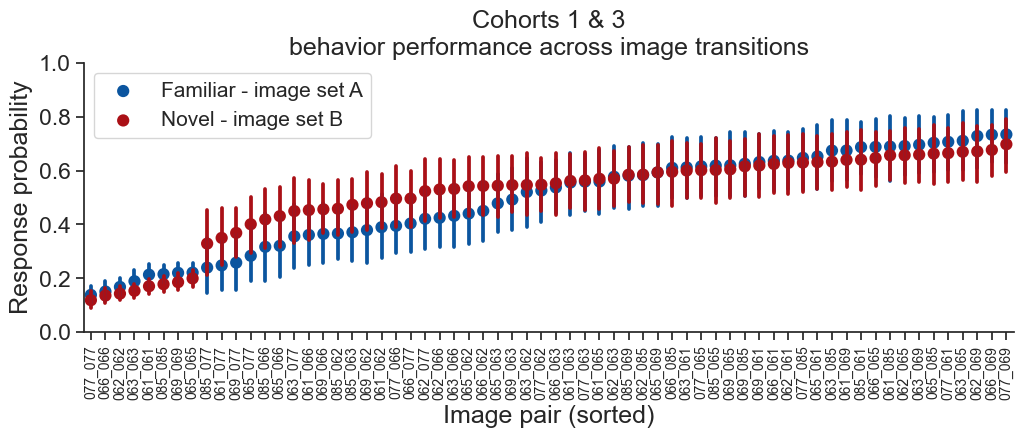

In [ ]:
colors = utils.get_colors_for_session_numbers()
colors = [colors[0], colors[3]]

order = np.sort(familiar_data.image_pair_index.unique())

figsize = (12, 3.5)
fig, ax = plt.subplots(figsize=figsize)

familiar_data = familiar_data.sort_values(by='image_pair_index')
order = familiar_data.image_pair_index.unique()
xticklabels = familiar_data.image_pair.unique()

ax = sns.pointplot(data=familiar_data, x='image_pair_index', y='response_probability', order=order, 
                      color=colors[0], label='Familiar - image set A', join=False, ax=ax)
ax = sns.pointplot(data=novel_data, x='image_pair_index', y='response_probability', order=order, 
                      color=colors[1], label='Novel - image set B', join=False, ax=ax)
ax.set_xticklabels(xticklabels, rotation=90, fontsize=10)
ax.set_xlabel('Image pair (sorted)')
ax.set_ylim(0, 1)
ax.legend(loc='upper left', fontsize='small')
ax.set_title('Cohorts 1 & 3\nbehavior performance across image transitions')
ax.set_ylabel('Response probability')

#### whats up with the images in the range where familiar is lower than novel? 

In [ ]:
low_perf_images = familiar_data[familiar_data.image_pair_index.isin(np.arange(8,32))].image_name.unique()

In [ ]:
familiar_experiment_id = platform_experiments[platform_experiments.behavior_session_id==familiar_data.behavior_session_id.values[0]].index.values[0]
dataset = loading.get_ophys_dataset(familiar_experiment_id)

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


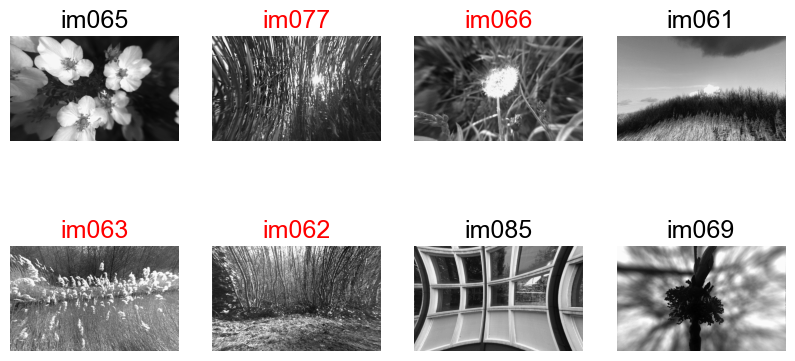

In [ ]:
stimulus_templates = dataset.stimulus_templates.copy()
fig, ax = plt.subplots(2,4,figsize=(10,5))
ax=ax.ravel()
for i,image_name in enumerate(stimulus_templates.index):
    ax[i].imshow(stimulus_templates.loc[image_name]['warped'], cmap='gray')
    if image_name in low_perf_images:
        color='r'
    else:
        color='k'
    ax[i].set_title(image_name, color=color)
    ax[i].axis('off')

These are generally the high spatial frequency images...

### which novel images are in the same range in the ordered set?

In [ ]:
novel_low_perf_images = novel_data[novel_data.image_pair_index.isin(np.arange(8,32))].image_name.unique()

In [ ]:
novel_experiment_id = platform_experiments[platform_experiments.behavior_session_id==novel_data.behavior_session_id.values[0]].index.values[0]
dataset = loading.get_ophys_dataset(novel_experiment_id)

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


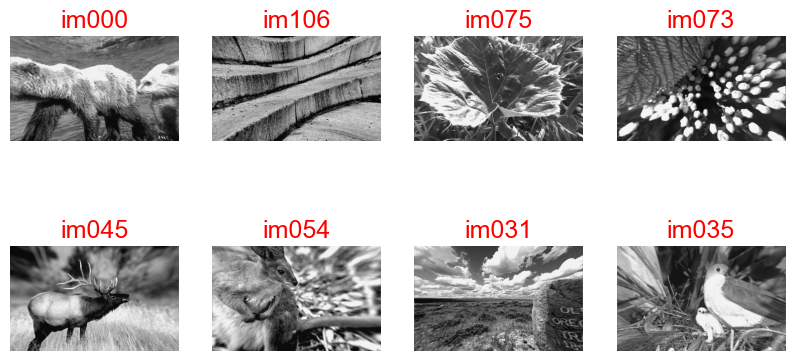

In [ ]:
stimulus_templates = dataset.stimulus_templates.copy()
fig, ax = plt.subplots(2,4,figsize=(10,5))
ax=ax.ravel()
for i,image_name in enumerate(stimulus_templates.index):
    ax[i].imshow(stimulus_templates.loc[image_name]['warped'], cmap='gray')
    if image_name in novel_low_perf_images:
        color='r'
    else:
        color='k'
    ax[i].set_title(image_name, color=color)
    ax[i].axis('off')

In [ ]:
novel_low_perf_images

array(['im073', 'im106', 'im075', 'im031', 'im035', 'im000', 'im054',
       'im045'], dtype=object)

In [ ]:
# does it matter what image it changed from?
novel_data[novel_data.image_pair_index.isin(np.arange(8,32))].previous_image_name.unique()

array(['im106', 'im075', 'im031', 'im035', 'im000', 'im054', 'im045'],
      dtype=object)

In [ ]:
np.sort(novel_data[novel_data.image_pair_index.isin(np.arange(8,32))].image_pair.unique())

array(['000_031', '000_035', '000_073', '000_075', '031_035', '031_073',
       '031_075', '031_106', '035_045', '035_073', '035_075', '035_106',
       '045_035', '045_054', '045_073', '045_075', '054_000', '054_031',
       '054_035', '054_073', '054_075', '075_035', '075_073', '106_073'],
      dtype=object)

### repeat for B-A mice

In [ ]:
familiar_sessions = behavior_sessions[(behavior_sessions.last_familiar_active==True) &
                                     (behavior_sessions.project_code.isin(['VisualBehaviorTask1B']))].index.values
novel_sessions = behavior_sessions[(behavior_sessions.first_novel==True) & 
                                  (behavior_sessions.project_code.isin(['VisualBehaviorTask1B']))].index.values
print(len(familiar_sessions), len(novel_sessions))

familiar_data = behavior.aggregate_response_probability_across_sessions(familiar_sessions, engaged_only=engaged_only)
novel_data = behavior.aggregate_response_probability_across_sessions(novel_sessions, engaged_only=engaged_only)

familiar_data = add_image_pair_column(familiar_data)
novel_data = add_image_pair_column(novel_data)

familiar_pair_order = familiar_data.groupby('image_pair').mean()[['response_probability']].sort_values(by='response_probability').index.values
novel_pair_order = novel_data.groupby('image_pair').mean()[['response_probability']].sort_values(by='response_probability').index.values

familiar_data = add_image_pair_index(familiar_data, familiar_pair_order)
novel_data = add_image_pair_index(novel_data, novel_pair_order)

22 22


C:\Users\marinag\AppData\Local\Temp\ipykernel_18940\2600042533.py:13: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  familiar_pair_order = familiar_data.groupby('image_pair').mean()[['response_probability']].sort_values(by='response_probability').index.values
C:\Users\marinag\AppData\Local\Temp\ipykernel_18940\2600042533.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  novel_pair_order = novel_data.groupby('image_pair').mean()[['response_probability']].sort_values(by='response_probability').index.values


Text(0, 0.5, 'Response probability')

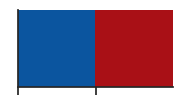

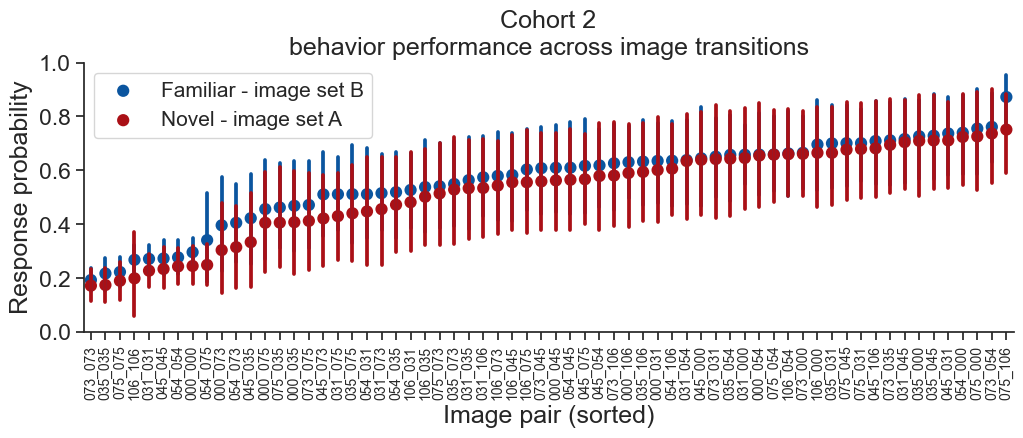

In [ ]:
colors = utils.get_colors_for_session_numbers()
colors = [colors[0], colors[3]]
sns.palplot(colors)

familiar_data = familiar_data.sort_values(by='image_pair_index')
order = familiar_data.image_pair_index.unique()
xticklabels = familiar_data.image_pair.unique()

figsize = (12, 3.5)
fig, ax = plt.subplots(figsize=figsize)


ax = sns.pointplot(data=familiar_data, x='image_pair_index', y='response_probability', order=order, 
                      color=colors[0], label='Familiar - image set B', join=False, ax=ax)
ax = sns.pointplot(data=novel_data, x='image_pair_index', y='response_probability', order=order, 
                      color=colors[1], label='Novel - image set A', join=False, ax=ax)
ax.set_xticklabels(xticklabels, rotation=90, fontsize=10)
ax.set_xlabel('Image pair (sorted)')
ax.set_ylim(0, 1)
ax.legend(loc='upper left', fontsize='small')
ax.set_title('Cohort 2\nbehavior performance across image transitions')
ax.set_ylabel('Response probability')

Difference isnt as bad, but it does indicate that image set A (which is Novel here, i.e. blue) does have images that are simply harder to detect

#### is it the same set of images that are harder to detect for image set A (Novel set in this case)?

C:\Users\marinag\Anaconda3\envs\visual_behavior_sdk\lib\site-packages\hdmf\spec\namespace.py:533: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.3.0 because version 1.5.0 is already loaded.
  % (ns['name'], ns['version'], self.__namespaces.get(ns['name'])['version']))


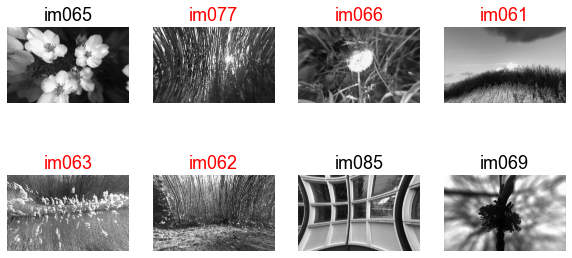

In [ ]:
low_perf_images = novel_data[novel_data.image_pair_index.isin(np.arange(8,22))].image_name.unique()

novel_experiment_id = platform_experiments[platform_experiments.behavior_session_id==novel_data.behavior_session_id.values[0]].index.values[0]
dataset = loading.get_ophys_dataset(familiar_experiment_id)

stimulus_templates = dataset.stimulus_templates.copy()
fig, ax = plt.subplots(2,4,figsize=(10,5))
ax=ax.ravel()
for i,image_name in enumerate(stimulus_templates.index):
    ax[i].imshow(stimulus_templates.loc[image_name]['warped'], cmap='gray')
    if image_name in low_perf_images:
        color='r'
    else:
        color='k'
    ax[i].set_title(image_name, color=color)
    ax[i].axis('off')